In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from torchvision.utils import make_grid
import torch
torch.autograd.set_detect_anomaly(True)
import time
import torch.optim as optim
from tqdm.auto import tqdm
from torch.autograd import Variable
from datetime import datetime
############################
import ipywidgets
import threading
import math
from sklearn.metrics import accuracy_score, f1_score, precision_score, precision_recall_curve, recall_score
import importlib
import torch.nn as nn


In [2]:
from skimage.segmentation import find_boundaries
from skimage.morphology import dilation, square
from skimage.segmentation import find_boundaries

In [3]:
import cython
%load_ext Cython

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [5]:
import utils_CAD as utc
import importlib
importlib.reload(utc)

params,paths = utc.get_params_paths()

paths = utc.get_paths(paths, verbose=True)

importlib.reload(utc)
paths = utc.get_initial_paths(paths,params)

nt
Code Running === Rashid-Unito :: Windows
path_results :  E:/Cloud/RashidPHD/Codes/DistriMuSe/AD_CAD_v3
path_datasets_main : D:/DS/VeleriaLab
current path:		 e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau
path_codes_local:	 E:/PHD/datacloud_data/repos/AD_CAD_v3\
path_codes_cloud:	 e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\
path_codes_local:	 E:/PHD/datacloud_data/repos/AD_CAD_v3\
path_codes_local:	 E:/PHD/datacloud_data/repos/AD_CAD_v3\
Path exists:		 E:/PHD/datacloud_data/repos/AD_CAD_v3\


In [6]:
paths.path_results_cloud = paths.path_codes_cloud

In [7]:
params.latent_dims = 64
params.latent_dims

64

In [8]:
import utils_model_CAD as utmc

In [9]:
importlib.reload(utc)
####################################################################################################
subgroup = 'PLeft'
# subgroup = 'PRight'

# subgroup = 'ConvBelt'
# subgroup = 'RoboArm'
# subgroup = 'full'
params.subgroup = subgroup


####################################################################################################

paths,params = utc.get_dataset_version(paths,params, dataset_version='V6',
                                            dataset_type='fronttop',
                                            mask_image_name=3015,
                                            subgroup=subgroup,
                                            verbose=True
                                            )

####################################################################################################
train_loader, train_dataset = utc.get_data_loaders_from_preprocessed(paths.train_dir_processed_subgroup,
                                                      batch_size=16,
                                                      augmentation_type='custom',
                                                      num_workers=0, 
                                                      pin_memory=False,
                                                      persistent_workers=False,
                                                      verbose=True)

paths.train_classes = {idx: cls for cls, idx in train_loader.dataset.class_to_idx.items()}

paths.class_names_train = train_loader.dataset.classes
# paths.test_classes =  {idx: cls for cls, idx in test_loader.dataset.class_to_idx.items()}
# paths.class_names_test = test_loader.dataset.classes
print('-'*120)

# print('augmentation type', params.aug_type)

filenames_loader = train_loader.dataset.imgs

print('Filenames found in dataloader', len(filenames_loader))
print(params.aug_type)
# print('Test Classes: ',paths.test_classes)
# train_loader.dataset.class_to_idx

------------------------------------------------------------------------------------------------------------------------
Paths SETUP COMPLETED for PLeft
----  DATA LOADER  ---- with ++ custom ++ Augmentation
train_dataset 6008  from  D:/DS/VeleriaLab\V6\fronttop\train_processed\PLeft
------------------------------------------------------------------------------------------------------------------------
Filenames found in dataloader 6008
auto-mask


In [10]:
importlib.reload(utc)
paths = utc.get_initial_paths(paths,params)
suffix,paths = utc.get_create_results_path(params.subgroup,params,paths,models_dir='models', save_path_type='cloud')
# paths.path_results_cloud

current path:		 e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau
path_codes_local:	 E:/PHD/datacloud_data/repos/AD_CAD_v3\fronttop
path_codes_cloud:	 e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop
path_codes_local:	 E:/PHD/datacloud_data/repos/AD_CAD_v3\fronttop
path_codes_local:	 E:/PHD/datacloud_data/repos/AD_CAD_v3\fronttop
Path exists:		 E:/PHD/datacloud_data/repos/AD_CAD_v3\fronttop
using suffix as --> PLeft_64
Component :  PLeft
------------------------------------------------------------------------------------------------------------------------
base_dir :  e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\
path_models :  e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\models
path_results :  e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\results/PLeft_64
results_test :  e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\test/PLeft_64
path_results_fix :  e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\monitor/PLeft_64


In [11]:
%%cython
import numpy as np
cimport numpy as cnp
from libc.math cimport sqrt, INFINITY

def compute_distance_offset(cnp.ndarray[cnp.float32_t, ndim=3] imgA, 
                            cnp.ndarray[cnp.float32_t, ndim=3] imgB, 
                            int offset):
    """Compute minimum Euclidean distance in a search kernel for each pixel."""
    
    # Assertions to ensure both images have the same shape and type
    assert imgA.shape[0] == imgB.shape[0], "Error: imgA and imgB must have the same height"
    assert imgA.shape[1] == imgB.shape[1], "Error: imgA and imgB must have the same width"
    assert imgA.shape[2] == imgB.shape[2], "Error: imgA and imgB must have the same channels"
    assert imgA.dtype == np.float32 and imgB.dtype == np.float32, "Error: Images must be of type float32"
    
    cdef int H = imgA.shape[0]
    cdef int W = imgA.shape[1]
    cdef int C = imgA.shape[2]  # Assuming 3 channels (RGB)
    assert C==3, "Error: input images should have three channels"
    
    cdef cnp.ndarray[cnp.float32_t, ndim=2] distance = np.zeros((H, W), dtype=np.float32)

    cdef int i, j, ki, kj
    cdef float min_dist, dist, diff

    for i in range(H):
        for j in range(W):
            min_dist = INFINITY  # Initialize with a high value
            
            # Search in the kernel centered at (i, j) in imgB
            for ki in range(max(0, i - offset), min(H, i + offset + 1)):
                for kj in range(max(0, j - offset), min(W, j + offset + 1)):
                    dist = 0.0
                    for c in range(C):  # Compute Euclidean distance per channel
                        diff = imgA[i, j, c] - imgB[ki, kj, c]
                        dist += diff * diff
                    
                    dist = sqrt(dist)  # Take the square root to get the Euclidean distance
                    
                    if dist < min_dist:
                        min_dist = dist
            
            distance[i, j] = min_dist  # Assign the minimum distance found
    
    return distance

In [12]:
from scipy.ndimage import gaussian_filter

def anomaly_score_offset_sigma(imgA, imgB, offset, sigma=None, quant=1.0):
    """
    Computes the max anomaly score using compute_distance() with a given offset and optional Gaussian smoothing.
    
    Parameters:
        imgA (np.ndarray): First image (H, W, 3), float32.
        imgB (np.ndarray): Second image (H, W, 3), float32.
        offset (int): Kernel width for compute_distance().
        sigma (float or None): Standard deviation for Gaussian filter (if None, no filter applied).
    
    Returns:
        float: Maximum value of the processed distance matrix.
    """
    # Compute distance matrix with given offset
    dist_matrix = compute_distance_offset(imgA, imgB, offset)
    
    # Apply Gaussian filter if sigma is provided
    if sigma is not None:
        dist_matrix = gaussian_filter(dist_matrix, sigma=sigma)
    
    # Return max value of the distance matrix, together with the distance matrix
    return np.quantile(dist_matrix, quant), dist_matrix

In [13]:
def plot_gauss_anomaly_maps(imgA,imgB):
    kernel_widths = [0, 1, 2]  # X-axis (offset)
    gaussian_sigmas = [None, 1, 2, 3]  # Y-axis (Gaussian smoothing)

    distance_matrices = {k: compute_distance_offset(imgA, imgB, k) for k in kernel_widths}

    # Create figure
    fig, axes = plt.subplots(len(gaussian_sigmas), len(kernel_widths), figsize=(12, 8))

    for row, sigma in enumerate(gaussian_sigmas):
        for col, kernel_width in enumerate(kernel_widths):
            # Get the base distance matrix
            dist_matrix = distance_matrices[kernel_width]
            
            # Apply Gaussian filter if sigma is not None
            if sigma is not None:
                dist_matrix = gaussian_filter(dist_matrix, sigma=sigma)
            
            # Plot
            ax = axes[row, col]
            im = ax.imshow(dist_matrix, cmap='Reds', vmin=0, vmax=0.25)
            ax.set_xticks([])  # Remove axis labels for clarity
            ax.set_yticks([])

            quantiles = [0.99, 0.999, 0.9999, 1]
            qv = np.quantile(dist_matrix, quantiles)
            msg = [f'q({q})={v}' for q,v in zip(quantiles,qv)]
            # msg.append(f'max={np.max(dist_matrix)}')

            ax.text(10, 120, '\n'.join(msg))
            
            # Titles
            if row == 0:
                ax.set_title(f"Offset = {kernel_width}", fontsize=12)
            if col == 0:
                ax.set_ylabel(f"sig = {sigma}" if sigma is not None else "No Filter", fontsize=12)

    # Adjust layout
    plt.tight_layout()
    plt.show()

In [14]:
AS_SIGMA = 1
AS_OFFSET = 1
AS_QUANT = 1.0

In [15]:
def get_anomaly_score(data_batch,recon_batch,offset=AS_OFFSET,sigma=AS_SIGMA,quant=AS_QUANT, debug = False):
    if debug:
        print('data_batch.shape',data_batch.shape)
        print('recon_batch.shape',recon_batch.shape)
        
    assert len(data_batch.shape)==4
    assert len(recon_batch.shape)==4
    assert (data_batch.shape[0]==recon_batch.shape[0] and data_batch.shape[1]==recon_batch.shape[1] and
            data_batch.shape[2]==recon_batch.shape[2] and data_batch.shape[3]==recon_batch.shape[3])
    
    scores, diff_images = [], []
    for i in range(data_batch.shape[0]):
        data_ = data_batch[i].detach().cpu().numpy()
        recon_batch_ = recon_batch[i].detach().cpu().numpy()
        data_ =  np.moveaxis(data_, 0, 2)
        recon_batch_ = np.moveaxis(recon_batch_, 0, 2)
        anomaly_score,diff_img = anomaly_score_offset_sigma(data_, recon_batch_, offset, sigma, quant)
        scores.append(anomaly_score)
        diff_images.append(diff_img)
        torch.cuda.empty_cache()
    return np.array(scores), np.array(diff_images)

In [16]:
%%cython
import numpy as np
cimport numpy as cnp
from libc.math cimport sqrt, INFINITY

def compute_sign_distance_offset(cnp.ndarray[cnp.float32_t, ndim=3] imgA, 
                                 cnp.ndarray[cnp.float32_t, ndim=3] imgB, 
                                 int offset):
    """Compute minimum (in absolute) signed distance in a search kernel for each pixel."""
    
    # Assertions to ensure both images have the same shape and type
    assert imgA.shape[0] == imgB.shape[0], "Error: imgA and imgB must have the same height"
    assert imgA.shape[1] == imgB.shape[1], "Error: imgA and imgB must have the same width"
    assert imgA.shape[2] == imgB.shape[2], "Error: imgA and imgB must have the same channels"
    assert imgA.dtype == np.float32 and imgB.dtype == np.float32, "Error: Images must be of type float32"
    
    cdef int H = imgA.shape[0]
    cdef int W = imgA.shape[1]
    cdef int C = imgA.shape[2]  # Assuming 3 channels (RGB)
    assert C==3, "Error: input images should have three channels"

    cdef cnp.ndarray[cnp.float32_t, ndim=3] sign_distance = np.zeros((H, W, C), dtype=np.float32)

    cdef int i, j, ki, kj
    cdef float min_dist, dist, diff

    for i in range(H):
        for j in range(W):
            min_dist = INFINITY  # Initialize with a high value
            min_delta = None
            
            # Search in the kernel centered at (i, j) in imgB
            for ki in range(max(0, i - offset), min(H, i + offset + 1)):
                for kj in range(max(0, j - offset), min(W, j + offset + 1)):
                    dist = 0.0
                    for c in range(C):  # Compute Euclidean distance per channel
                        diff = imgA[i, j, c] - imgB[ki, kj, c]
                        dist += diff * diff
                    
                    if dist < min_dist:
                        min_dist = dist
                        min_delta = (ki, kj)
            
            ki, kj = min_delta
            for c in range(C):
                sign_distance[i, j, c] = imgA[i, j, c] - imgB[ki, kj, c]
    
    return sign_distance

In [17]:
####################################################################################################
def get_l1_difference(real_images,reconstructed_images,supress_output=False):
        """Computes L1 (absolute) difference between original and reconstructed images."""
        diff_map = torch.abs(real_images - reconstructed_images)  # (B, C, H, W)
        diff_score = diff_map.mean(dim=(1, 2, 3)).detach().cpu().numpy()  # (B,)
        if supress_output:
            diff_map = diff_map.cpu().numpy()
            diff_map = np.moveaxis(diff_map, 1, 3)  # (B, C, H, W) → (B, H, W, C)
            diff_map = np.mean(diff_map, axis=-1)  # Convert to grayscale
            diff_map = diff_map[0]  # Select first image in batch
        del diff_map
        return diff_score
####################################################################################################
def get_l2_difference(real_images,reconstructed_images):
        """Computes L2 (Euclidean) difference per pixel and overall score."""
        # diff_map = (real_images - reconstructed_images) ** 2  # Pixel-wise squared difference
        diff_score = torch.norm(real_images - reconstructed_images, p=2, dim=(1, 2, 3)).detach().cpu().numpy()  # (B,)
        # if supress_output:
        #     diff_map = diff_map.cpu().numpy()
        #     diff_map = np.moveaxis(diff_map, 1, 3)  # (B, C, H, W) → (B, H, W, C)
        #     diff_map = np.mean(diff_map, axis=-1)  # Convert to grayscale
        #     diff_map = diff_map[0]  # Select first image in batch
        # del diff_map
        return diff_score
####################################################################################################
from skimage.metrics import structural_similarity as ssim
def get_ssim_dissimilarity_batch(real_images,reconstructed_images, ssim_type='ssim', ssim_params=None,
                                 win_size=None, gaussian_weights=None,sigma=None,
                                 supress_output=False):
        #########################################################################

        if ssim_params is not None:
            win_size, gaussian_weights,sigma = ssim_params['win_size'], ssim_params['gaussian_weights'],ssim_params['sigma']
        if ssim_params is not None and win_size is None and gaussian_weights is None and sigma is None:
            win_size,gaussian_weights,sigma = 3,True,1.5
        else:
             assert win_size is not None and gaussian_weights is not None and sigma is not None, "ssim_params should be provided"
                 
        use_sample_covariance = False

        batch_size = real_images.shape[0]
        maps, scores = [], []

        for i in range(batch_size):

            data_img = real_images[i].detach().cpu().numpy()
            recon_img = reconstructed_images[i].detach().cpu().numpy()

            data_img = np.moveaxis(data_img, 0, 2)  # (C, H, W) → (H, W, C)
            recon_img = np.moveaxis(recon_img, 0, 2)  

            # Normalize images to [0,1] range
            data_img = (data_img - data_img.min()) / (data_img.max() - data_img.min() + 1e-8)
            recon_img = (recon_img - recon_img.min()) / (recon_img.max() - recon_img.min() + 1e-8)

            # Compute SSIM similarity score and similarity map
            ssim_score, ssim_map = ssim(data_img, recon_img, data_range=1.0, 
                                        win_size=win_size,sigma = sigma,full=True,
                                        gaussian_weights=gaussian_weights,use_sample_covariance=use_sample_covariance
                                        )
            
            if ssim_type == 'ssim-d':
                ssim_result_map = 1 - ssim_map  
                ssim_result_score = 1 - ssim_score  # Convert SSIM score to dissimilarity
            else:
                ssim_result_map = ssim_map
                ssim_result_score = ssim_score

            maps.append(ssim_result_map)
            scores.append(ssim_result_score)
        maps = np.array(maps)
        scores = np.array(scores)
        # print('ssim==+==++==++ ',maps.shape, scores.shape)

        # maps = np.moveaxis(maps, 3, 1)  # (B, C, H, W) → (B, H, W, C)
        # print('maps first',maps.shape)
        if supress_output:
            # diff_map = diff_map.cpu().numpy()
            # diff_map = np.moveaxis(diff_map, 1, 3)  # (B, C, H, W) → (B, H, W, C)
            maps = np.mean(maps, axis=-1)  # Convert to grayscale
            # print('maps',maps.shape)
            maps = maps[0]  # Select first image in batch
            # print('maps',maps.shape)
        # print('ssim==+==++==++ ',maps.shape, scores.shape)
        
        return scores
######################################
def get_ssim_dissimilarity_baatch_maps(real_images,reconstructed_images, ssim_type='ssim', ssim_params=None,
                                 win_size=None, gaussian_weights=None,sigma=None,
                                 supress_output=False):
        #########################################################################

        if ssim_params is not None:
            win_size, gaussian_weights,sigma = ssim_params['win_size'], ssim_params['gaussian_weights'],ssim_params['sigma']
        elif len(params)==0:
             pass
        else:
            win_size,gaussian_weights,sigma = 3,True,1.5
            
        use_sample_covariance = False

        batch_size = real_images.shape[0]
        maps, scores = [], []

        for i in range(batch_size):

            data_img = real_images[i].detach().cpu().numpy()
            recon_img = reconstructed_images[i].detach().cpu().numpy()

            data_img = np.moveaxis(data_img, 0, 2)  # (C, H, W) → (H, W, C)
            recon_img = np.moveaxis(recon_img, 0, 2)  

            # Normalize images to [0,1] range
            data_img = (data_img - data_img.min()) / (data_img.max() - data_img.min() + 1e-8)
            recon_img = (recon_img - recon_img.min()) / (recon_img.max() - recon_img.min() + 1e-8)

            # Compute SSIM similarity score and similarity map
            ssim_score, ssim_map = ssim(data_img, recon_img, data_range=1.0, 
                                        win_size=win_size,sigma = sigma,full=True,
                                        gaussian_weights=gaussian_weights,use_sample_covariance=use_sample_covariance
                                        )
            
            if ssim_type == 'ssim-d':
                ssim_result_map = 1 - ssim_map  
                ssim_result_score = 1 - ssim_score  # Convert SSIM score to dissimilarity
            else:
                ssim_result_map = ssim_map
                ssim_result_score = ssim_score

            maps.append(ssim_result_map)
            scores.append(ssim_result_score)
        maps = np.array(maps)
        scores = np.array(scores)
        # print('ssim==+==++==++ ',maps.shape, scores.shape)

        # maps = np.moveaxis(maps, 3, 1)  # (B, C, H, W) → (B, H, W, C)
        # print('maps first',maps.shape)
        if supress_output:
            # diff_map = diff_map.cpu().numpy()
            # diff_map = np.moveaxis(diff_map, 1, 3)  # (B, C, H, W) → (B, H, W, C)
            maps = np.mean(maps, axis=-1)  # Convert to grayscale
            # print('maps',maps.shape)
            maps = maps[0]  # Select first image in batch
            # print('maps',maps.shape)
        # print('ssim==+==++==++ ',maps.shape, scores.shape)
        
        return maps

In [18]:
# def get_anomaly_score_ravi(real_images, reconstructed_images, quantile=1.0):
#     abs_diffs = torch.abs(real_images - reconstructed_images)
#     mean_diffs = abs_diffs.mean(dim=1).cpu().detach().numpy()
#     mean_diffs = mean_diffs.reshape(mean_diffs.shape[0], -1)
#     scores = np.quantile(mean_diffs, q=quantile, axis=1)
#     return scores

def get_anomaly_score_distance_offset_quant(real_images, reconstructed_images, offset=1, quantile=1.0, sigma=0):
    real_images_np = real_images.permute(0, 2, 3, 1).cpu().detach().numpy().astype(np.float32)
    reconstructed_images_np = reconstructed_images.permute(0, 2, 3, 1).cpu().detach().numpy().astype(np.float32)
    
    batch_scores = []
    for real_img, recon_img in zip(real_images_np, reconstructed_images_np):
        # sign_distances = compute_sign_distance_offset(real_img, recon_img, offset)
        sign_distances = image_reconstruction_signed_similarity_map(real_img, recon_img, offset=offset, sigma=sigma)
        max_score = np.quantile(np.abs(sign_distances), q=quantile)
        batch_scores.append(max_score)
    
    return np.array(batch_scores)


In [19]:
# Hyperparameters
params.epochs = epochs = 1000
params.batch_size   = 8
params.latent_dims  = 64

# params.exp_type = 'E1'
# params.exp_type = 'E2'
params.exp_type = 'E3'

# params.learning_rate_enc_dec  = 0.001  # 
# params.learning_rate_dis      = 0.0001 # should be 10x smaller that enc_dec to improve convergence
kl_usuage                     = True


In [20]:
importlib.reload(utc)
suffix,paths = utc.get_create_results_path(params.subgroup,params,paths,models_dir='models')


using suffix as --> PLeft_64
Component :  PLeft
------------------------------------------------------------------------------------------------------------------------
base_dir :  E:/PHD/datacloud_data/repos/AD_CAD_v3\fronttop
path_models :  E:/PHD/datacloud_data/repos/AD_CAD_v3\fronttop\models
path_results :  E:/PHD/datacloud_data/repos/AD_CAD_v3\fronttop\results/PLeft_64
results_test :  E:/PHD/datacloud_data/repos/AD_CAD_v3\fronttop\test/PLeft_64
path_results_fix :  E:/PHD/datacloud_data/repos/AD_CAD_v3\fronttop\monitor/PLeft_64


In [21]:
params = utc.get_parameters_by_experiment(params, verbose=True)
_ = utc.get_header(params,paths, verbose=True)

Parameters for experiment E3 are set:
Learning rate enc_dec: 0.001
Learning rate dis: 0.0001
Beta KL: 0.0001
Beta GAN: 0.0001
Reconstruction loss function: MSE
Adversarial loss function: BCWithLogits
|  dataset   |   camera   |  subgroup  |  epochs   |   latent_dims   |   input_shape   | batch_size |   LR_enc_dec    |     LR_dis      |
----------------------------------------------------------------------------------------------------------------------------------------------------------------
|     V6     |  fronttop  |   PLeft    |    1000    |       64        |    3x128x128    |     8      |      0.001      |     0.0001      |


In [22]:
importlib.reload(utc)
from utils_model_CAD import Encoder, Decoder, Discriminator

# Loss functions
reconstruction_loss_fn = nn.MSELoss()  # L2 reconstruction loss
adversarial_loss_fn = nn.BCEWithLogitsLoss()  # For GAN

Enc = Encoder(z_size=params.latent_dims).to(device)
Dec = Decoder(z_size=params.latent_dims).to(device)
Dis = Discriminator().to(device)

# Optimizers
optEncDec = optim.Adam(list(Enc.parameters()) + list(Dec.parameters()), lr=params.learning_rate_enc_dec)
optDis = optim.Adam(Dis.parameters(), lr=params.learning_rate_dis)

suffix,paths = utc.get_create_results_path(params.subgroup,params,paths,models_dir='models', save_path_type='cloud')
# loss_history = []  # List of dictionaries to accumulate loss values
loss_history = utmc.load_model(Enc, Dec, Dis, optEncDec, optDis, paths, suffix, verbose=True)
print('='*100)
print('model trained?', len(loss_history))
print('='*100)

using suffix as --> PLeft_64
Component :  PLeft
------------------------------------------------------------------------------------------------------------------------
base_dir :  e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop
path_models :  e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop\models
path_results :  e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop\results/PLeft_64
results_test :  e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop\test/PLeft_64
path_results_fix :  e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop\monitor/PLeft_64
TRYING MODEL FROM -> e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop\models\model_PLeft_64.pt
Loaded model from e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop\models\model_PLeft_64.pt
Model loaded at epoch 1000
model trained? 1000


In [23]:
INFERENCE_FROM_VIDEO = True
# INFERENCE_FROM_VIDEO = False


In [24]:
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

transform = transforms.Compose([
    transforms.ToPILImage(),      # Convert OpenCV image to PIL
    # transforms.Resize((128, 128)),  # Resize frame
    transforms.ToTensor()         # Convert to tensor (C, H, W)
])

In [25]:
if INFERENCE_FROM_VIDEO:
    def get_inference_videos(anomaly_type='unexpected_person'):
        if anomaly_type == 'unexpected_person':
            ext = '.avi'
            input_video_ = 'fronttop_video'
            segmentation_video_= 'fronttopsegmentation_video'

        elif anomaly_type == 'unexpected_person_entering':
            ext = '.mp4'
            input_video_ = 'fronttop_video'
            segmentation_video_= 'fronttopsegmentation_video'

            # input_video_name = f'fronttop_video.{ext}'
            # segmentation_video_name= 'fronttopsegmentation_video.avi'
        input_video_name = f'{input_video_}{ext}'
        segmentation_video_name= f'{segmentation_video_}.avi'
        
        return input_video_name, segmentation_video_name, ext


    anomaly_type = 'unexpected_person'
    # anomaly_type = 'unexpected_person_entering'
    def get_video_path(anomaly_type = 'unexpected_person'):
        if anomaly_type == 'unexpected_person':
            ds_version = 'v6'
        elif anomaly_type == 'unexpected_person_entering':
            ds_version = 'v7'
        return ds_version

    input_video_name, segmentation_video_name, ext = get_inference_videos(anomaly_type=anomaly_type)
    ds_version = get_video_path(anomaly_type=anomaly_type)

    input_video_path= f'D:/DS/VeleriaLab/{ds_version}/fronttop/test_video/{anomaly_type}/{input_video_name}'
    seg_video_path= f'D:/DS/VeleriaLab/{ds_version}/fronttop/test_video/{anomaly_type}/{segmentation_video_name}'

    # Create dataset

    image_dataset_video = utc.StreamVideoDataset(input_video_path, transform=transform)
    segments_dataset_video = utc.StreamVideoDataset(seg_video_path, transform=transform)

    # DataLoader to stream frames
    images_loader_video = DataLoader(image_dataset_video, batch_size=1, shuffle=False)
    segments_loader_video = DataLoader(segments_dataset_video, batch_size=1, shuffle=False)


    print('input_video_path\t\t\t', input_video_path)
    print('seg_video_path\t\t\t\t', seg_video_path)

    print('Total frames in video:\t\t\t', len(image_dataset_video))
    print('Total frames in segmentation video:\t', len(segments_dataset_video))


input_video_path			 D:/DS/VeleriaLab/v6/fronttop/test_video/unexpected_person/fronttop_video.avi
seg_video_path				 D:/DS/VeleriaLab/v6/fronttop/test_video/unexpected_person/fronttopsegmentation_video.avi
Total frames in video:			 5664
Total frames in segmentation video:	 5664


In [26]:
from scipy.ndimage import gaussian_filter

def image_reconstruction_signed_similarity_map(imgA, imgB, offset=1, sigma=0):
    sng_dist_mat = compute_sign_distance_offset(imgA, imgB, offset)
    if sigma > 0:
        # sng_dist_mat = gaussian_filter(sng_dist_mat, sigma=sigma)
        sng_dist_mat[:,:,0] = gaussian_filter(sng_dist_mat[:,:,0], sigma=sigma)
        sng_dist_mat[:,:,1] = gaussian_filter(sng_dist_mat[:,:,1], sigma=sigma)
        sng_dist_mat[:,:,2] = gaussian_filter(sng_dist_mat[:,:,2], sigma=sigma)
    # sng_dist_mat = np.mean(np.abs(sng_dist_mat), axis=2)
    sng_dist_mat = np.sqrt(np.sum(np.square(sng_dist_mat), axis=2)) # Euclidean distance
    return sng_dist_mat

def image_reconstruction_similarity_map(imgA, imgB, offset=1, sigma=0):
    dist_mat = compute_distance_offset(imgA, imgB, offset)
    if sigma > 0:
        dist_mat = gaussian_filter(dist_mat, sigma=sigma)
    return dist_mat

In [27]:
from utils_CAD import get_anomaly_score_ravi

In [28]:
simple_test = False
# simple_test = True


anomaly_scores_fn = [
    ('Ravi',                get_anomaly_score_ravi,               image_reconstruction_similarity_map),
    ('Ravi-Q', lambda i,r : get_anomaly_score_ravi(i,r, 0.99999), image_reconstruction_similarity_map),
    ('L1',                  get_l1_difference                   , image_reconstruction_similarity_map), # L1 absolute difference
    ('L2',                  get_l2_difference                   , image_reconstruction_similarity_map), # L2 Euclidean difference per pixel and overall score
    ('SSIMd',  lambda i,r : get_ssim_dissimilarity_batch(i,r,ssim_type='ssim-d', ssim_params = opt),image_reconstruction_similarity_map), 
    # Computes SSIM-based dissimilarity maps (1 - SSIM)
    
    # ('S1diff', get_anomaly_score_distance_offset_quant),
    # ('S1diff-Q', lambda i,r : get_anomaly_score_distance_offset_quant(i,r, 1, 0.99999)),
    # ('S2diff', lambda i,r : get_anomaly_score_distance_offset_quant(i,r, 2)),
    # ('S3diff', lambda i,r : get_anomaly_score_distance_offset_quant(i,r, 3)),
    # ('S2diff-Q', lambda i,r : get_anomaly_score_distance_offset_quant(i,r, 2, 0.99999)),
    # ('S2diff-G', lambda i,r : get_anomaly_score_distance_offset_quant(i,r, 2, quantile=1.0, sigma=1)),
    # ('S2diff-g', lambda i,r : get_anomaly_score_distance_offset_quant(i,r, 2, quantile=1.0, sigma=0.5)),
    # ('S2diff-QG', lambda i,r : get_anomaly_score_distance_offset_quant(i,r, 2, quantile=0.99999, sigma=1)),
    # ('S2diff-GG', lambda i,r : get_anomaly_score_distance_offset_quant(i,r, 2, quantile=1.0, sigma=1.5)),
    # ('S2diff-QGG', lambda i,r : get_anomaly_score_distance_offset_quant(i,r, 2, quantile=0.99999, sigma=1.5)),
]
###################################################################################################
## SIMPLE OFFSET DISTANCE

###################################################################################################
if simple_test:
    win_size_ls             = [1]
    sigma_ls                = [1.0]
    gaussian_weights_ls     = [False, True]
    aggregation_function_ls = ['max', 'q-99', 'q-999']
else:
    win_size_ls             = [1, 3]
    sigma_ls                = [1.0, 1.5, 2.0]
    gaussian_weights_ls     = [False, True]
    aggregation_function_ls = ['max', 'q-99', 'q-999']

###################################################################################################
for win_size in win_size_ls:
    for gaussian_weights in gaussian_weights_ls:
        for sigma in sigma_ls:
            anomaly_scores_fn.append((f'SSIM-w{win_size}-g{gaussian_weights}-s{sigma}', 
                                lambda i,r, win_size=win_size, gaussian_weights=gaussian_weights, sigma=sigma: 
                                    get_ssim_dissimilarity_batch(i,r,ssim_type='ssim-d',
                                                                 win_size=win_size,
                                                                 gaussian_weights=gaussian_weights,
                                                                 sigma=sigma),
                                lambda i,r, win_size=win_size, gaussian_weights=gaussian_weights, sigma=sigma: 
                                    get_ssim_dissimilarity_batch_maps(i, r,ssim_type='ssim-d',
                                                                      win_size=win_size,
                                                                      gaussian_weights=gaussian_weights,
                                                                      sigma=sigma)))
###################################################################################################
if simple_test:
    offset_ls = [1]
    quantile_ls = [1.0]
    sigma_ls = [0.5, 1.0, 1.5]
else:
    offset_ls = [1,2,3]
    quantile_ls = [1.0, 0.999, 0.99]
    # quantile_ls = [1.0, 0.999, 0.99, 0.98, 0.95]

    sigma_ls = [0, 0.5, 1.0, 1.5]

###################################################################################################

for offset in offset_ls:
    for quantile in quantile_ls:
        for sigma in sigma_ls:
            anomaly_scores_fn.append((f'OFF-o{offset}-q{quantile}-s{sigma}', 
                                   lambda i,r, offset=offset, quantile=quantile, sigma=sigma: 
                                        get_anomaly_score_distance_offset_quant(i,r, offset=offset, quantile=quantile, sigma=sigma),
                                   lambda i,r, offset=offset, sigma=sigma: 
                                        image_reconstruction_signed_similarity_map(i, r, offset=offset, sigma=sigma)))
###################################################################################################
print ('total anomaly_scores --> ', len(anomaly_scores_fn))

# for name,_,_ in anomaly_scores_fn:
#     print(name)

total anomaly_scores -->  53


In [29]:
import utils_model_CAD as utm

reconstruction_loss_fn, adversarial_loss_fn = utm.get_loss_functions(verbose=True)

# reconstruction_loss_fn = nn.MSELoss()  # L2 reconstruction loss
# adversarial_loss_fn = nn.BCEWithLogitsLoss()  # For GAN

Enc = utm.Encoder(z_size=params.latent_dims).to(device)
Dec = utm.Decoder(z_size=params.latent_dims).to(device)
Dis = utm.Discriminator().to(device)

# Optimizers
optEncDec, optDis = utm.get_optimizers(Enc, Dec, Dis, verbose=True)

# suffix,paths = utc.get_create_results_path(component,params,paths, save_path_type='cloud')
# loss_history = []  # List of dictionaries to accumulate loss values
loss_history = utm.load_model(Enc, Dec, Dis, optEncDec, optDis, paths, suffix, verbose=True)


Loss functions initialized:
Reconstruction Loss Function:  MSELoss()
Adversarial Loss Function:  BCEWithLogitsLoss()
TRYING MODEL FROM -> e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop\models\model_PLeft_64.pt
Loaded model from e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop\models\model_PLeft_64.pt
Model loaded at epoch 1000


In [30]:
def load_tuned_threshold(paths, params,component=None, VERBOSE=False, sort_by='binormal_AUC'):
    if component is None:
        return None, None, None, None
    
    save_dir = f'{paths.path_codes_main}/threshold/plots_anomaly_results-{component}'
    csv_path = os.path.join(save_dir, f"anomaly_metrics_{component}.csv")
    if os.path.exists(csv_path):
        # os.remove(csv_path)
        df = pd.read_csv(csv_path, index_col=0)
        df['original_index'] = df.index
        df['original_position'] = range(len(df))

        sorted_df = df.sort_values(by= sort_by, ascending=False)
        if VERBOSE:
            print('subgroup :', component)
            print(f'LOADING THRESHOLD FILE FROM {csv_path}')
        # df.head()
        best_anom_score, \
            best_anomaly_score_index,\
                best_threshold = sorted_df.iloc[0].name, sorted_df.iloc[0].original_position,sorted_df.iloc[0].Threshold

        return best_anom_score, best_anomaly_score_index, best_threshold, sorted_df
    else:
        raise FileNotFoundError(f"CSV file not found at {csv_path}")

In [31]:
import copy

importlib.reload(utc)
components_ls = ['PLeft']#, 'bg']

# components_ls = ['PLeft','RoboArm','PRight','ConvBelt']#, 'bg']
# components_ls = ['PLeft','RoboArm','PRight']#, 'bg']
# components_ls = ['full']
models_dict = {}

PLOT_TRAINING_CURVES = False
# PLOT_TRAINING_CURVES = True
print('LOADING DETECTORS')
print('-'*100)
for component in components_ls:
    # params.subgroup = component
    params.subgroup_mask = 'mask'
    params.aug_type = f'auto-{params.subgroup_mask}'
    suffix, paths = utc.get_create_results_path(component,params, paths, save_path_type='cloud', verbose=False)
    # print(suffix)
    # Deep copy the model structures
    enc = copy.deepcopy(Enc)
    dec = copy.deepcopy(Dec)
    dis = copy.deepcopy(Dis)
    
    # Initialize optimizers
    optEncDec, optDis = utm.get_optimizers(Enc, Dec, Dis, verbose=False)

    # Load models
    loss_history = utm.load_model(enc, dec, dis, optEncDec, optDis, paths, suffix, verbose=False)
    
    # Store in dictionary
    models_dict[component] = {
        'encoder': enc,
        'decoder': dec,
        'discriminator': dis,
        'optEncDec': optEncDec,
        'optDis': optDis,
        'path': os.path.join(paths.path_models, f"model_{suffix}.pt")
    }
    if PLOT_TRAINING_CURVES:
        utc.plot_loss_sep(loss_history, params, paths, destroy_fig=False)
print('-'*100)


LOADING DETECTORS
----------------------------------------------------------------------------------------------------
using suffix as --> PLeft_64
----------------------------------------------------------------------------------------------------


In [32]:
def plot_anomalymaps(diff_img,component,idx,video_savepath_part,color_score,normscore_text,norm_score,fontsize=10,destroy_figs = False):
    fig = plt.figure(figsize=(4, 4))

    plt.imshow(diff_img, cmap=threshold_cmap if norm_score<1 else threshold_cmap_unexpected, vmin=0, vmax=2*selected_threshold)
    plt.title(f"{component} - N-Score: {normscore_text}", 
              color=color_score, 
              fontsize=fontsize)
    plt.xticks([])
    plt.yticks([])

    plt.savefig(f'{video_savepath_part}/{component}_anommap_{idx}.png', dpi=150, bbox_inches='tight')
    if destroy_figs:
        plt.close(fig)
    plt.show()


In [33]:
def load_masks(components,image, mask_image_name=3015, verbose=False):
    components_masks,components_masked_full,masked_cropped_component = {},{},{}
    for component in components:
        mask_name = f'{paths.dataset_type}_{mask_image_name}_{component}_{params.subgroup_mask}_ext.png'
        mask_path = os.path.join(paths.mask_dir, mask_name)
        if not os.path.exists(mask_path):
            raise FileNotFoundError(f"Mask not found at {mask_path}")
        print(mask_path)
        base_mask = Image.open(mask_path).convert("L").resize(image.size, Image.LANCZOS)
        base_mask = base_mask.point(lambda p: 255 if p > 128 else 0)
        base_mask = base_mask.convert("L")
        masked_full_image = Image.composite(image, Image.new("RGB", image.size, (0, 0, 0)), base_mask)
        components_masks[component] = np.array(base_mask)
        components_masked_full[component] = np.array(masked_full_image)
        
        masked_cropped_image = transform_crop(masked_full_image)
        masked_cropped_image_show = TF.to_pil_image((masked_cropped_image * 0.5 + 0.5).clamp(0, 1))  # De-normalize for display
        masked_cropped_component[component] = masked_cropped_image_show
    return components_masks,components_masked_full,masked_cropped_component
        # components_masks[componcomponents_masked_fullent] = 
# components_masks,components_masked_full = load_masks(components_ls)

In [34]:
import cv2

def resize_full_frame_from_VAE(x, target_size=params.target_size, full_frame_size=(1280, 720),calculated_resize=(227,128), verbose=False):
    if verbose:
        print('x shape before resize:', x.shape)    
    x_resized = cv2.resize(x, (calculated_resize))
    if verbose:
        print('x shape before resize:', x.shape)
    return x_resized
# plt.imshow(resize_full_frame_from_VAE(orig_img))

In [35]:
def plot_full_frame_flow(x_in,x_out,x_diff, rescale_image = True, save_plot=True):
    # fig,axes = plt.subplots(1,3,figsize=(10,5))
    if rescale_image:
        fig,axes = plt.subplots(1,3,figsize=(15,10))
        x_in = resize_full_frame_from_VAE(x=x_in)
        x_out = resize_full_frame_from_VAE(x=x_out)
        x_diff = resize_full_frame_from_VAE(x=x_diff)
    else:
        fig,axes = plt.subplots(1,3,figsize=(10,5))
    axes[0].imshow(x_in * 0.5 +0.5)
    axes[1].imshow(x_out * 0.5 +0.5)
    axes[2].imshow(x_diff,cmap = threshold_cmap_unexpected, vmin=0, vmax=2)
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.1, hspace=0.1)
    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
    
    plt.show()

In [36]:
def plot_final_results_v4(
    image, full_anomaly_map, full_recon_image,
    components_masks, comp_map_list, components_ls,
    batch_scores_component, component_threshold, video_savepath, idx,
    anomaly_score_method=None, component_level_anomaly=True, rescale_image_to_full=False,
    save_svg = False,
    fontsize=18, plot_title=True, destroy_figs=False, VERBOSE=True, dpi=300
):
    """
    Displays anomaly detection results (3 subplots in a single row):
      1) Input image + component boundaries + status text
      2) Anomaly map + component boundaries + status text
      3) Reconstructed image + component boundaries
    """
    full_desp_for_components = {
        'PLeft': 'Pallet Left',
        'PRight': 'Pallet Right',
        'RoboArm': 'Robotic Arm',
        'ConvBelt': 'Conveyor Belt',
        'full': 'Full Image',
    }

    # --- Create figure: 1 row, 3 columns ---
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    ax_input_img, ax_anom_img, ax_recon_img = axes

    if component_level_anomaly:
        # Prepare boundary overlay (used for all subplots)
        contour_overlay = np.zeros((*full_anomaly_map.shape[:2], 4))

    for component in components_ls:
        norm_score = batch_scores_component[component] / component_threshold[component]
        is_anomalous = norm_score > 1

        if component_level_anomaly:
            boundaries = find_boundaries(np.array(components_masks[component]), mode='thick')
            thickness = 4 if is_anomalous else 1
            thick_boundaries = dilation(boundaries, square(thickness))
            boundary_color = (1, 0, 0, 1) if is_anomalous else (0, 0, 0, 1)
        else:
            if rescale_image_to_full:
                image = image * 0.5 + 0.5
                full_recon_image = full_recon_image * 0.5 + 0.5
                image = resize_full_frame_from_VAE(x=image)
                full_anomaly_map = resize_full_frame_from_VAE(x=full_anomaly_map)
                full_recon_image = resize_full_frame_from_VAE(x=full_recon_image)

        if component_level_anomaly:
            contour_overlay[thick_boundaries] = boundary_color

            # bounding box coords
            y, x = np.where(components_masks[component])

            if len(y) > 0 and len(x) > 0:
                #-------------------
                if component == 'ConvBelt':
                    center_x = np.mean(x)
                    bottom_y = np.max(y) -95
                    text_align = 'center'
                #-------------------
                elif component == 'PLeft':
                    center_x = np.min(x) - (150 if is_anomalous else 25)
                    bottom_y = np.max(y) + 10
                    text_align = 'left'
                #-------------------
                elif component == 'PRight':
                    center_x = np.min(x) - (20 if is_anomalous else -40)
                    bottom_y = np.max(y) + 10
                    text_align = 'left'
                #-------------------
                elif component == 'RoboArm':
                    center_x = np.mean(x) + (100 if is_anomalous else 170)
                    bottom_y = np.min(y) + 15
                    text_align = 'right'
                #-------------------
                else:
                    # fallback if you add new components later
                    center_x = np.mean(x)
                    bottom_y = np.min(y)
                    text_align = 'center'
            else:
                # fallback (should rarely happen)
                center_x = 0
                bottom_y = 0
                text_align = 'left'

            status = "UnExp" if is_anomalous else "Norm"
            text = f"{status}:{norm_score:.2f}"

            text_props = {
                'x': center_x,
                'y': bottom_y,
                's': text,
                'color': 'red' if is_anomalous else 'black',
                'fontsize': fontsize,
                'ha': text_align,
                'va': 'top',
                'bbox': {
                    'facecolor': 'white',
                    'alpha': 0.7,
                    'edgecolor': 'red' if is_anomalous else 'green',
                    'boxstyle': 'round,pad=0.2'
                }
            }

            # Add text to BOTH subplots (input + anomaly)
            ax_input_img.text(**text_props)
            ax_anom_img.text(**text_props)

        if VERBOSE and idx == 0:
            print(
                f"{component:<10}: (tau: {component_threshold[component]:<10.3f}) "
                f"(Score: {norm_score:<10.3f} {'unexpected' if is_anomalous else 'normal'})"
            )

    # ===== Plot 1: Original Image =====
    ax_input_img.imshow(image)
    if component_level_anomaly:
        ax_input_img.imshow(contour_overlay, alpha=0.7)

    # ===== Plot 2: Anomaly Map =====
    ax_anom_img.imshow(full_anomaly_map, cmap=threshold_cmap_unexpected, vmin=0, vmax=2)
    if component_level_anomaly:
        ax_anom_img.imshow(contour_overlay, alpha=0.7)

    # ===== Plot 3: Reconstructed Image =====
    ax_recon_img.imshow(full_recon_image)
    if component_level_anomaly:
        ax_recon_img.imshow(contour_overlay, alpha=0.7)

    if plot_title:
        ax_input_img.set_title("(A) Input with detections scores", pad=3, fontsize=fontsize+4)
        ax_anom_img.set_title("(B) Anomaly Map", pad=3, fontsize = fontsize+4)
        ax_recon_img.set_title("(C) Reconstructed Image", pad=3, fontsize = fontsize+4)

    # Remove ticks
    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])

    # plt.tight_layout()
    plt.subplots_adjust(wspace=0.05, hspace=0.05)
    plt.savefig(f'{video_savepath}/detections_{idx}.png', dpi=dpi, bbox_inches='tight')
    if save_svg:
        plt.savefig(f'{video_savepath}/detections_{idx}.svg', dpi=dpi, bbox_inches='tight')

    if destroy_figs and not idx == 0:
        plt.close(fig)

    plt.show()


In [37]:
paths.threshold_results = os.path.join(paths.path_codes,paths.dataset_type, 'threshold_results')
os.makedirs(paths.threshold_results, exist_ok=True)
csv_filename_anomaly_scores_train = f'{paths.threshold_results}/train_{paths.dataset_type}_{params.subgroup}_anomaly_scores_{AS_OFFSET}_{AS_SIGMA}_{AS_QUANT}.csv'

In [38]:
importlib.reload(utc)

if os.path.exists(csv_filename_anomaly_scores_train):
    df_train = pd.read_csv(csv_filename_anomaly_scores_train, index_col=None)
    print(f'CSV file loaded {csv_filename_anomaly_scores_train}')
    df_train.head(2)
else:                           
    print(f'CSV file not found {csv_filename_anomaly_scores_train}')


CSV file loaded e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop\threshold_results/train_fronttop_PLeft_anomaly_scores_1_1_1.0.csv


In [39]:
def get_index_used_for_calibration(offset=1,sigma=1.0,quan=1.0):

    for ind,(as_name, as_mm, as_mmm) in enumerate(anomaly_scores_fn):
        if as_name.startswith('OFF'):
            as_name_o = as_name.split('-')
            if as_name_o[1]==f'o{offset}' and as_name_o[2]==f'q{quan}' and as_name_o[-1]==f's{sigma}':
                # print('FOUND ')
            
                # print(ind, as_name, as_mm, as_mmm)
                return ind, as_name, as_mm, as_mmm
        # print(ind, as_name, as_name_o,'\t', (as_name_o[1]=='o1' and as_name_o[2]=='q1.0'), as_name_o[1])
    

In [40]:

csv_filename_anomaly_scores_val = (
    f'{paths.threshold_results}/val_{paths.dataset_type}_{params.subgroup}_anomaly_scores_{AS_OFFSET}_{AS_SIGMA}_{AS_QUANT}.csv'
)

if os.path.exists(csv_filename_anomaly_scores_val):
    print(csv_filename_anomaly_scores_val)
    df_val_loaded = pd.read_csv(csv_filename_anomaly_scores_val)
    display(df_val_loaded)


e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop\threshold_results/val_fronttop_PLeft_anomaly_scores_1_1_1.0.csv


,file_name,anomaly_score,label
0,fronttop_0004,0.071818,0
1,fronttop_0009,0.072340,0
2,fronttop_0014,0.078602,0
3,fronttop_0019,0.072073,0
4,fronttop_0024,0.070745,0
...,...,...,...
1196,fronttop_5984,0.074583,0
1197,fronttop_5989,0.066254,0
1198,fronttop_5994,0.063476,0
1199,fronttop_5999,0.058600,0


In [41]:
best_anomaly_score_index,best_anom_score,*_ = get_index_used_for_calibration(offset=1,sigma=1.0,quan=1.0)
 
top_1_fname,best_threshold = df_val_loaded.loc[df_val_loaded.anomaly_score.idxmax()].file_name, df_val_loaded.loc[df_val_loaded.anomaly_score.idxmax()].anomaly_score

top_1_fname.split('_')[-1], best_threshold

best_threshold

1.6234904527664185

In [42]:
best_score_name, best_score_fn, best_score_imgdiff = anomaly_scores_fn[best_anomaly_score_index]
selected_threshold = (best_threshold * 1.0)
print('best_anomaly_score_index : \t', best_anomaly_score_index)
print('selected_threshold \t: \t',selected_threshold)
print('Safety Area \t\t:\t', params.subgroup)
# show_all = False  # Set to True to display all samples
show_all = True  # Set to True to display all samples
print('Anomaly Score Function \t: \t', best_score_name)

best_anomaly_score_index : 	 19
selected_threshold 	: 	 1.6234904527664185
Safety Area 		:	 PLeft
Anomaly Score Function 	: 	 OFF-o1-q1.0-s1.0


In [43]:
from PIL import Image, ImageOps

  0%|          | 0/5664 [00:00<?, ?it/s]

IndexError: index 2 is out of bounds for axis 0 with size 2

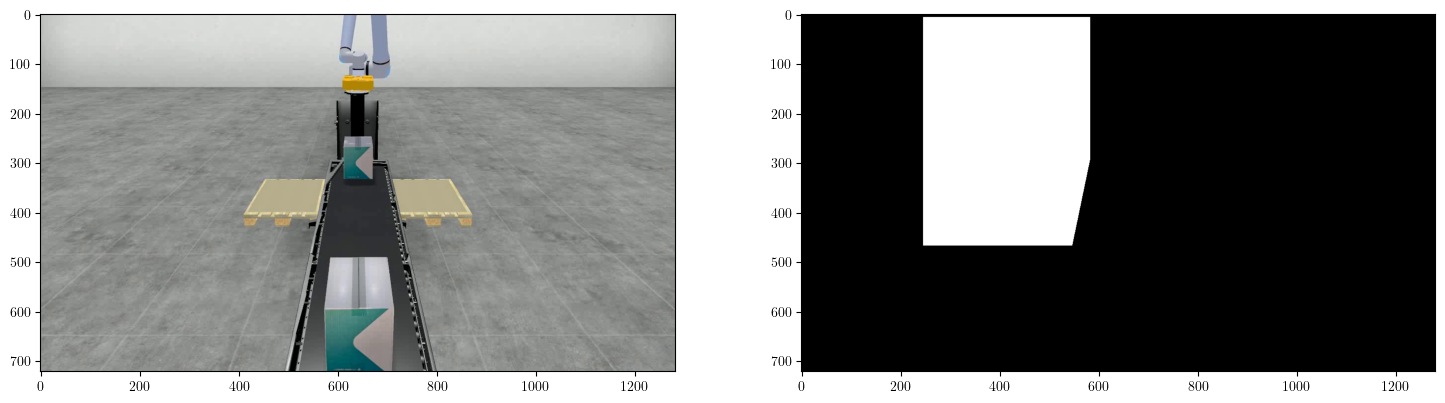

In [65]:
# components_ls = ['PLeft','ConvBelt','PRight','RoboArm']#, 'bg']
# components_ls = ['RoboArm']#, 'bg']
mask_image_name = 3015
target_size = tuple(params.target_size)  # (H,W)
VERBOSE = True
for idx, (frame,fidx) in enumerate(tqdm(images_loader_video)):

    frame_np = (frame.squeeze(0).cpu().numpy().transpose(1, 2, 0) * 255).astype('uint8')
    image = Image.fromarray(frame_np).convert("RGB")  # Now RGB

    full_anomaly_map = np.zeros((image.size[1], image.size[0]))  # (H, W)
    
    component_tensors = []
    component_plots = []
    # plt.figure(figsize=(6, 6))
    # plt.imshow(image)
    ##################
    fig,axs = plt.subplots(1,len(components_ls)+1,figsize=(18, 6))
    inputs_encoder = []
    for i, component in enumerate(components_ls):
            # Assume you already have this initialized:
        

        # transform_crop = transforms.Compose([
        #     CustomCrop(component, params.map_coor),   # Just the cropping part
        #     transforms.Resize(target_size),
        #     transforms.ToTensor(),
        #     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        # ])
        # crop_x, crop_y, crop_w, crop_h = params.map_coor[component]
        # if VERBOSE:
        #     print(component, crop_x, crop_y, crop_w, crop_h)

        # Load component-specific mask
        component_mask_path = os.path.join(paths.mask_dir, f"{paths.dataset_type}_{mask_image_name}_{component}_{params.subgroup_mask}_ext.png")
        
        if not os.path.exists(component_mask_path):
            if VERBOSE or idx == 0:
                print(f"Component mask not found: {component_mask_path}")
            continue

        component_mask = np.array(Image.open(component_mask_path).convert("L"))#.resize(image.size, Image.LANCZOS)
        component_mask = (component_mask > 128).astype(np.float32) #.point(lambda p: 1.0 if p > 128 else 0)

        component_mask_3chan = np.stack([component_mask] * 3, axis=-1)  # Convert to 3 channels
        
        # plt.imshow(component_mask_3chan)
        axs[0].imshow(image)
        axs[1].imshow(component_mask_3chan)

        input_pil = Image.fromarray((frame_np * component_mask_3chan).astype('uint8')).convert("RGB")
        
        axs[2].imshow(input_pil)

        transform_crop_masked = transforms.Compose([
            utc.MaskedCrop(subgroup=component, mask=component_mask.astype('bool')),   # Just the cropping part
            transforms.Resize(target_size),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ])
        input_encoder = transform_crop_masked(input_pil).unsqueeze(0)
        inputs_encoder.append(input_encoder)
        # print(input_encoder.shape, type(input_encoder))
    for i, component in enumerate(components_ls):
        # print(component, inputs_encoder[i].shape, type(inputs_encoder[i]))

        input_encoder = inputs_encoder[i][0].cpu().numpy().transpose(1, 2, 0)* 0.5 + 0.5
        axs[i+1].imshow(input_encoder)
        axs[i+1].set_title(f"{component}")
    
    for ax in axs:
        ax.set_xticks([])
        ax.set_yticks([])
    
    break

In [66]:
def load_tuned_threshold_fixed_best(paths,component,decided_best_scorer = f'OFF-o1-q0.999-s1.5'):
    if component is None:
        return None, None, None, None

    for valss in anomaly_scores_fn:

        if valss[0]==decided_best_scorer:
            best_scorer_row = valss[0]

    save_dir = f'{paths.path_codes_main}/threshold/plots_anomaly_results-{component}'
    csv_path = os.path.join(save_dir, f"anomaly_metrics_{component}.csv")
    if os.path.exists(csv_path):
        if component=='ConvBelt':
            df = pd.read_csv(csv_path, index_col=0)
            row = df.iloc[0]
            return row.name, None, row.Threshold
        else:
            df = pd.read_csv(csv_path, index_col=0)
            df['original_index'] = df.index
            df['original_position'] = range(len(df))
            
            row = df.loc[best_scorer_row]
            return row.name, None, row.Threshold
    else:
        raise FileNotFoundError(f"CSV file not found at {csv_path}")

In [67]:
def get_best_scorer_call(decided_best_scorer = f'OFF-o1-q0.999-s1.5'):
    for valss in anomaly_scores_fn:
        if valss[0]==decided_best_scorer:
            best_scorer_row = valss
    return best_scorer_row
# get_best_scorer_call(decided_best_scorer = f'OFF-o1-q0.999-s1.5')

In [68]:
params.anomaly_type = anomaly_type = 'unexpected_person'

In [69]:
csv_file_inference_path = os.path.join(f'{os.path.join(paths.path_codes,paths.dataset_type)}/inference', f'csv_{params.anomaly_type}')

In [70]:
for idx, (frame,fidx) in enumerate(tqdm(images_loader_video)):
    frame_np = (frame.squeeze(0).cpu().numpy().transpose(1, 2, 0) * 255).astype('uint8')
    image = Image.fromarray(frame_np).convert("RGB")  # Now RGB
    break

  0%|          | 0/5664 [00:00<?, ?it/s]

In [71]:
# # threshold_cmap

# threshold_cmap_unexpected = LinearSegmentedColormap.from_list("custom_threshold_cmap", 
#                                                 [(0.0, "white"),
#                                                 (0.25, "lightblue"),
#                                                 # (0.35, "coral"),
#                                                 (0.50, "red"),
#                                                 (1.0, "purple") ])


# threshold_cmap = LinearSegmentedColormap.from_list("custom_threshold_cmap", 
#                                                 [(0.0, "white"),
#                                                 (0.5, "lightblue"),
#                                                 (0.5, "purple"),
#                                                 (1.0, "red") ])

In [72]:
# anom_type = 'unexpected_person'
paths.path_labeling = f'{paths.path_results_cloud}/labeling_result'
os.makedirs(paths.path_labeling, exist_ok=True)
csv_filename_anom_metadata = f'{paths.path_labeling}/csv_anomaly_metadata_{params.anomaly_type}.csv'

paths.test_dir_cropped = os.path.join(paths.test_dir, f'cropped_{params.anomaly_type}')

importlib.reload(utc)

if os.path.exists(csv_filename_anom_metadata):
    print(f'FILE OK :{csv_filename_anom_metadata}')

    df_anom_meta = pd.read_csv(csv_filename_anom_metadata, index_col=None)

    sub_group_count = df_anom_meta.groupby('component').size().reset_index(name='count')
    display(sub_group_count)
else:
    print(f'FILE NOT FOUND : {csv_filename_anom_metadata}')

df_anom_meta = df_anom_meta[['frame_no', 'image_anomaly', 'component', 'component_anomaly']]
df_anom_meta.head(5)

FILE OK :e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop/labeling_result/csv_anomaly_metadata_unexpected_person.csv


,component,count
0,ConvBelt,5861
1,PLeft,5861
2,PRight,5861
3,RoboArm,5861


,frame_no,image_anomaly,component,component_anomaly
0,0,NORMAL,PLeft,NORMAL
1,0,NORMAL,ConvBelt,NORMAL
2,0,NORMAL,PRight,NORMAL
3,0,NORMAL,RoboArm,NORMAL
4,1,NORMAL,PLeft,NORMAL


In [73]:
df_anom_meta[(df_anom_meta.component=='PRight') & (df_anom_meta.component_anomaly=='ANOMALOUS')].head(10)

,frame_no,image_anomaly,component,component_anomaly
2238,559,ANOMALOUS,PRight,ANOMALOUS
2246,561,ANOMALOUS,PRight,ANOMALOUS
2250,562,ANOMALOUS,PRight,ANOMALOUS
2254,563,ANOMALOUS,PRight,ANOMALOUS
2258,564,ANOMALOUS,PRight,ANOMALOUS
2262,565,ANOMALOUS,PRight,ANOMALOUS
2266,566,ANOMALOUS,PRight,ANOMALOUS
2270,567,ANOMALOUS,PRight,ANOMALOUS
2274,568,ANOMALOUS,PRight,ANOMALOUS
2278,569,ANOMALOUS,PRight,ANOMALOUS


In [74]:
paths.test_dir_base = paths.test_dir
paths.test_dir_base 

'D:/DS/VeleriaLab\\V6\\fronttop\\test'

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


dataset 6008


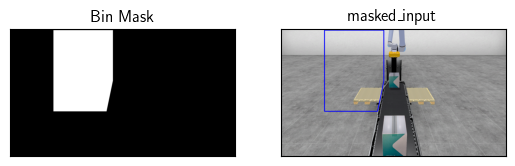

In [75]:
importlib.reload(utc)
train_loader_, train_dataset = utc.get_data_loaders_for_contour(
paths,
params,
root_dir=paths.train_dir,
subgroup=component,
aug_type='auto-contour',
batch_size=1,
shuffle=False,
mask_image_name=paths.mask_image_name,
num_workers=0,
pin_memory=False,
persistent_workers=False
)
real_batch = np.transpose(next(iter(train_loader_))[0][0].cpu().detach().numpy()* 0.5 + 0.5, (1, 2, 0))

# img_ = real_batch   
contoured_image,component_mask = utc.get_contoured_image(real_batch,paths,
                                                            subgroup=component,
                                                            mask_image_name = paths.mask_image_name, 
                                                    contour_color=(0,0,255),
                                                    thickness=4,
                                                    )
fig, axes = plt.subplots(1,2)

axes[0].imshow(component_mask, cmap='gray')
# plt.show()    
axes[1].imshow(contoured_image)
for ax,ttl in zip(axes, ['Bin Mask','masked_input']):
    ax.set_title(ttl)
    ax.set_xticks([])
    ax.set_yticks([])
# plt.xticks([])
# plt.yticks([])
plt.show()

In [76]:
from torchvision.transforms import functional as TF

masked_cropper = utc.MaskedCrop(subgroup=params.subgroup, mask=component_mask.astype('bool'))

transform_crop = transforms.Compose([
            # MaskedCrop(subgroup=component, mask=component_mask.astype('bool')),   # Just the cropping part
            masked_cropper,
            transforms.Resize(params.target_size),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ])

In [77]:
TEST_THRESHOLD_ON_WINNER = True

if TEST_THRESHOLD_ON_WINNER:
    best_anom_scorer, best_anom_scorer_fn, _ = anomaly_scores_fn[best_anomaly_score_index]
    print(f'{"best_anom_score":<30} {best_anom_score}')
    print(f'{"best_anomaly_score_index":<30} {best_anomaly_score_index} ')
    print(f'{"best_threshold":<30} {best_threshold}' )


best_anom_score                OFF-o1-q1.0-s1.0
best_anomaly_score_index       19 
best_threshold                 1.6234904527664185


In [78]:
def get_threshold_from_val_set(component, verbose=False):
    csv_filename_anomaly_scores_val = (
        f'{paths.threshold_results}/val_{paths.dataset_type}_{component}_anomaly_scores_{AS_OFFSET}_{AS_SIGMA}_{AS_QUANT}.csv'
    )

    if os.path.exists(csv_filename_anomaly_scores_val):
        if verbose:
            print(csv_filename_anomaly_scores_val)
        df_val_loaded = pd.read_csv(csv_filename_anomaly_scores_val)

    return df_val_loaded.loc[df_val_loaded.anomaly_score.idxmax()].anomaly_score

In [79]:
best_anom_component = {}
best_anom_score_component = {}
best_anomaly_score_index_component = {}
best_threshold_component = {}
# Load tuned thresholds for each component
for i, component in enumerate(components_ls):
    best_threshold_component[component] = get_threshold_from_val_set(component)

    best_anom_scorer, best_anom_scorer_fn, _ = anomaly_scores_fn[best_anomaly_score_index]
    best_anom_score_component[component] = best_anom_scorer

    print(f'for component: {component:<10} | {"using ASorer":<10} : {best_anom_score_component[component]:<25} | {"Threshold":<10}{best_threshold_component[component]}')
    print('-'*100)

for component: PLeft      | using ASorer : OFF-o1-q1.0-s1.0          | Threshold 1.6234904527664185
----------------------------------------------------------------------------------------------------


In [80]:
# PLOT_INTERMEDIATE = False
PLOT_INTERMEDIATE = True
# video_type= 'unexpected_person_fronttop_video.avi'
# video_type= 'unexpected_person_fronttop_video.avi'
# video_type= 'fronttop_video.avi'
# # video_type= 'unexpected_fronttop_video.avi'

# # video_path= f'D:\\DS\\VeleriaLab\\V6\\fronttop\\unexpected_data.mp4'
# video_path= f'D:\DS\VeleriaLab\V6/fronttop/test_video/unexpected_person/{video_type}'

video_savepath = os.path.join(f'{os.path.join(paths.path_codes,paths.dataset_type)}/inference', f'full_video_{params.anomaly_type}')
video_savepath_part = os.path.join(f'{os.path.join(paths.path_codes,paths.dataset_type)}/inference',f'full_video_{params.anomaly_type}', 'part')
video_savepath_part_comp = os.path.join(f'{os.path.join(paths.path_codes,paths.dataset_type)}/results',f'full_video_{input_video_name}', 'comparison')

os.makedirs(video_savepath, exist_ok=True)
os.makedirs(video_savepath_part, exist_ok=True)
# os.makedirs(video_savepath_part_comp, exist_ok=True)

# dataset_video = utc.StreamVideoDataset(video_path, transform=transform)

# # DataLoader to stream frames
# frame_loader = DataLoader(dataset_video, batch_size=1, shuffle=False)
# # print('video_path',video_path)
print('video_savepath',video_savepath)
print('video_savepath_part',video_savepath_part)



video_savepath e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop/inference\full_video_unexpected_person
video_savepath_part e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop/inference\full_video_unexpected_person\part


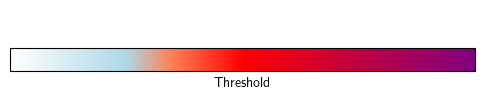

In [81]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap

threshold_cmap_unexpected = LinearSegmentedColormap.from_list("custom_threshold_cmap", 
                                                [(0.0, "white"),
                                                (0.25, "lightblue"),
                                                (0.35, "coral"),
                                                (0.50, "red"),
                                                (1.0, "purple") ])
# Create figure and axis
fig, ax = plt.subplots(figsize=(6, 1))

# Create ScalarMappable with same normalization as the imshow
norm = plt.Normalize(vmin=0, vmax=2*selected_threshold)
sm = ScalarMappable(cmap=threshold_cmap_unexpected, norm=norm)
sm.set_array([])

# Create colorbar
cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.5, pad=0.05)
cbar.set_label('Threshold')  # Optional label
cbar.set_ticks([])  # Hide tick values

ax.axis('off')  # Only show colorbar
plt.show()

In [82]:
def plot_intermedidate_figs(inpu,recon,diff_img,component,idx,video_savepath_part,
                            norm_score,color_score,normscore_text,thres_text,batch_scores,
                            threshold_values=None,
                            destroy_figs = False):
    threshold_cmap, threshold_cmap_unexpected, selected_threshold =  threshold_values
    fig, axxes = plt.subplots(1, 3, figsize=(12, 6))
    ax1,ax2,ax3 = axxes[0],axxes[1],axxes[2]
    ax1.imshow(inpu)
    ax1.set_title(f'Frame {idx}')
    ax2.imshow((recon* 0.5 + 0.5).squeeze(0).cpu().numpy().transpose(1, 2, 0))
    ax2.set_title('Reconstructed')
    

    ax3.imshow(diff_img, cmap=threshold_cmap if norm_score<1 else threshold_cmap_unexpected,
                vmin=0, vmax=2*selected_threshold)
    
    # ax3.set_title(f'{component} AM')
    
    # print(component,'[',np.min(comp_map_list[component]),'~',np.max(comp_map_list[component]),']')
    ax3.set_title(f"{component} - {thres_text}\nN-Score: {normscore_text}× \n score: {batch_scores:.4f}", 
                    color=color_score, 
                    fontsize=10)
    for ax in axxes:
        ax.set_xticks([])
        ax.set_yticks([])

    plt.savefig(f'{video_savepath_part}/{component}_inter_anomaly_map_{idx}.png', dpi=300, bbox_inches='tight')
    if destroy_figs:
        plt.close(fig)
    plt.show()


# threshold_cmap_list = [threshold_cmap, threshold_cmap_unexpected]


In [83]:
# _,best_score_name,best_score_fn,best_score_imgdiff = get_index_used_for_calibration(offset=1,sigma=1.0,quan=1.0)
# best_score_name,best_score_fn,best_score_imgdiff

In [84]:
importlib.reload(utc)

params.anomalous_type = anomaly_type

paths.segments = os.path.join(paths.path_datasets, 'fronttop/test_segmentation/fronttopsegmentation_unexpectedperson')
imgs_folder = os.path.join(paths.path_datasets, f'fronttop/test/{params.anomalous_type}/')
# components_ls = ['PLeft','PRight']#, 'bg']
# components_ls = ['PLeft','RoboArm','ConvBelt','PRight']#, 'bg']

# components_ls = ['PLeft','ConvBelt','PRight','RoboArm']#, 'bg']
for i, component in enumerate(components_ls):
    # get_data_loaders_for_process
    importlib.reload(utc)
    test_loader, test_dataset, segments_loader, segments_dataset = utc.get_data_loaders_for_contour_and_gt(
        paths,
        params,
        image_to_safety_area = True,
        root_dir=imgs_folder,
        subgroup=component,
        aug_type='auto-contour',
        batch_size=1,
        shuffle=False,
        # shuffle=True,
        mask_image_name=mask_image_name,
        num_workers=0,
        pin_memory=False,
        persistent_workers=False
    )
    
    # Pick a random index
    index = 2989
    # index = random.randint(len(train_dataset)/2, len(train_dataset) - 1)
    image_tensor, _ = test_dataset[index]
    seg_tensor,_      = segments_dataset[index]
    # params.subgroup = component
    # Denormalize if necessary
    real_batch = np.transpose(image_tensor.numpy() * 0.5 + 0.5, (1, 2, 0))
    real_batch_segments = np.transpose(seg_tensor.numpy() * 0.5 + 0.5, (1, 2, 0))
    print('-'*100)
    # print(real_batch.shape)
    

LOADING subgroup as -->  PLeft
dataset 5864
segmentation_masks 5864
----------------------------------------------------------------------------------------------------


In [85]:
test_loader, test_dataset, segments_loader, segments_dataset = utc.get_data_loaders_for_contour_and_gt(
        paths,
        params,
        image_to_safety_area = True,
        root_dir=imgs_folder,
        subgroup=params.subgroup,
        aug_type='auto-contour',
        batch_size=1,
        shuffle=False,
        # shuffle=True,
        mask_image_name=mask_image_name,
        num_workers=0,
        pin_memory=False,
        persistent_workers=False
    )
imgs_folder

LOADING subgroup as -->  PLeft
dataset 5864
segmentation_masks 5864


'D:/DS/VeleriaLab\\V6\\fronttop/test/unexpected_person/'

In [86]:
paths.test_dir = imgs_folder
paths.test_dir

'D:/DS/VeleriaLab\\V6\\fronttop/test/unexpected_person/'

In [87]:
importlib.reload(utc)
print('test dir ', paths.test_dir)
frame_loader, frame_dataset = utc.get_data_loaders_from_preprocessed(train_dir_processed_subgroup=paths.test_dir,
                                                      batch_size=1,
                                                      augmentation_type='min',
                                                      num_workers=0, 
                                                      pin_memory=False,
                                                      shuffle = False,
                                                      persistent_workers=False,
                                                      verbose=True)

paths.train_classes = {idx: cls for cls, idx in frame_loader.dataset.class_to_idx.items()}

paths.class_names_test = frame_loader.dataset.classes
# paths.test_classes =  {idx: cls for cls, idx in test_loader.dataset.class_to_idx.items()}
# paths.class_names_test = test_loader.dataset.classes
print('-'*120)

# print('augmentation type', params.aug_type)

filenames_loader = frame_loader.dataset.imgs

print('Filenames found in dataloader', len(filenames_loader))
print(params.aug_type)

print(f'paths.class_names_test', paths.class_names_test)

test dir  D:/DS/VeleriaLab\V6\fronttop/test/unexpected_person/
----  DATA LOADER  ---- with ++ min ++ Augmentation
train_dataset 5864  from  D:/DS/VeleriaLab\V6\fronttop/test/unexpected_person/
------------------------------------------------------------------------------------------------------------------------
Filenames found in dataloader 5864
auto-mask
paths.class_names_test ['unexpected_person']


In [88]:
# print(f'df_inference FRAMES : {len(df_inference_frame_level.frame_no.unique())} - {list(df_inference_frame_level.status.unique())}')

print(f'df_anom_meta FRAMES : {len(df_anom_meta.frame_no.unique())} - {list(df_anom_meta.image_anomaly.unique())}')
# print(f'df_anom_meta FRAMES : {len(df_anom_meta.frame_no.unique())} - {list(df_anom_meta.image_anomaly.unique())}')

df_anom_meta FRAMES : 5861 - ['NORMAL', 'ANOMALOUS']


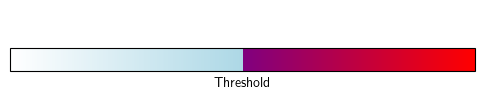

In [89]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap
# Create a custom colormap
best_threshold = 0.05
selected_threshold = best_threshold
threshold_cmap = LinearSegmentedColormap.from_list("custom_threshold_cmap", 
                                                [(0.0, "white"),
                                                (0.5, "lightblue"),
                                                (0.5, "purple"),
                                                (1.0, "red") ])

# Create figure and axis
fig, ax = plt.subplots(figsize=(6, 1))

# Create ScalarMappable with same normalization as the imshow
norm = plt.Normalize(vmin=0, vmax=2*selected_threshold)
sm = ScalarMappable(cmap=threshold_cmap, norm=norm)
sm.set_array([])

# Create colorbar
cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.5, pad=0.05)
cbar.set_label('Threshold')  # Optional label
cbar.set_ticks([])  # Hide tick values

ax.axis('off')  # Only show colorbar
plt.show()

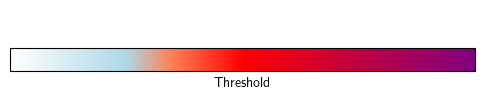

In [90]:
threshold_cmap_unexpected = LinearSegmentedColormap.from_list("custom_threshold_cmap", 
                                                [(0.0, "white"),
                                                (0.25, "lightblue"),
                                                (0.35, "coral"),
                                                (0.50, "red"),
                                                (1.0, "purple") ])
# Create figure and axis
fig, ax = plt.subplots(figsize=(6, 1))

# Create ScalarMappable with same normalization as the imshow
norm = plt.Normalize(vmin=0, vmax=2*selected_threshold)
sm = ScalarMappable(cmap=threshold_cmap_unexpected, norm=norm)
sm.set_array([])

# Create colorbar
cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.5, pad=0.05)
cbar.set_label('Threshold')  # Optional label
cbar.set_ticks([])  # Hide tick values

ax.axis('off')  # Only show colorbar
plt.show()

In [91]:
def get_image(images_loader_video):
    for idx, (frame,fidx) in enumerate(tqdm(images_loader_video)):
        frame_np = (frame.squeeze(0).cpu().numpy().transpose(1, 2, 0) * 255).astype('uint8')
        image = Image.fromarray(frame_np).convert("RGB")  # Now RGB
        return image
image = get_image(images_loader_video)

  0%|          | 0/5664 [00:00<?, ?it/s]

In [92]:
df_anom_meta[(df_anom_meta['component']==params.subgroup) & (df_anom_meta['component_anomaly']=='ANOMALOUS')].head(5)

,frame_no,image_anomaly,component,component_anomaly
4256,1064,ANOMALOUS,PLeft,ANOMALOUS
4260,1065,ANOMALOUS,PLeft,ANOMALOUS
4264,1066,ANOMALOUS,PLeft,ANOMALOUS
4268,1067,ANOMALOUS,PLeft,ANOMALOUS
4272,1068,ANOMALOUS,PLeft,ANOMALOUS


## INFERENCE WITHOUT MAPS

In [93]:
anomaly_level = 'componentlevel'

In [94]:
csv_file_inference_path_images = f'{csv_file_inference_path}_from_images_{anomaly_level}_fullimage'
video_savepath_article = os.path.join(video_savepath, 'for_article_drop')
os.makedirs(video_savepath_article, exist_ok=True)

csv_file_inference_path_images, video_savepath_article

('e:\\Cloud\\RashidPHD\\Codes\\DistriMuSe\\AD_CAD_v3_new_tau\\fronttop/inference\\csv_unexpected_person_from_images_componentlevel_fullimage',
 'e:\\Cloud\\RashidPHD\\Codes\\DistriMuSe\\AD_CAD_v3_new_tau\\fronttop/inference\\full_video_unexpected_person\\for_article_drop')

In [95]:
best_anom_component             = {}
best_anom_score_component       = {}
best_anomaly_score_index_component = {}
best_threshold_component = {}
#============================================
upscale_factor = 1
#============================================
# Load tuned thresholds for each component
for i, component in enumerate(components_ls):
    best_threshold_component[component] = get_threshold_from_val_set(component) * upscale_factor

    best_anom_scorer, best_anom_scorer_fn, _ = anomaly_scores_fn[best_anomaly_score_index]
    best_anom_score_component[component] = best_anom_scorer

    print(f'for component: {component:<10} | {"using ASorer":<10} : {best_anom_score_component[component]:<25} | {"Threshold":<10}{best_threshold_component[component]}')
    print('-'*100)

for component: PLeft      | using ASorer : OFF-o1-q1.0-s1.0          | Threshold 1.6234904527664185
----------------------------------------------------------------------------------------------------


In [96]:
increase_ratio = {'PLeft':0.8,
                  'RoboArm':0.8,
                  'PRight':0.8,
                  'ConvBelt':0.8,
                  }



In [97]:
print(csv_file_inference_path_images)

e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop/inference\csv_unexpected_person_from_images_componentlevel_fullimage


In [98]:
import os, glob
import torch.nn.functional as F
import numpy as np
import cv2
import torchvision.utils as vutils
from collections import defaultdict
from datetime import datetime
from tqdm.auto import tqdm

# ------------------------------------------------------------------------------------------------------------
# components_ls = ['PRight','PLeft']

VERBOSE = False

PLOT_INTERMEDIATE = False
#=================================================#=================================================#=================================================
#=================================================
INCREASE_THRESHOLD = False
INCREASE_THRESHOLD = False

#=================================================#=================================================#=================================================
dpi = 200
save_interval  = 10
#----------------------------------------
# run_on_selected_frame = True
run_on_selected_frame = False
#----------------------------------------
if run_on_selected_frame:
    allowed_frame_for_article = [564]
destroy_figs = True
plot_title = True
# ------------------------------------------------------------------------------------------------------------
image = get_image(images_loader_video)
components_masks, components_masked_full, masked_cropped_component = load_masks(components_ls, image)
print('-'*100)
best_anom_component = {}
#------------------------------------
# skip_plot = False
skip_plot = True
#------------------------------------
data_to_csv_component = []
data_to_csv_frame = []

print(f'STARTING INFERENCE USING {len(frame_loader)} frames')
# ----------------------------------------------------
for idx, (frame, fidx) in enumerate(tqdm(frame_loader)):
    time_start_frame = datetime.now()
    #================= UNCOMMENT THESE LINES FOR SELECTED FRAMES
    if run_on_selected_frame:
        if idx not in allowed_frame_for_article:
            if idx > max(allowed_frame_for_article):
                # destroy_figs = False  # keep last figs for viewing
                # break
                pass
            else:
                # pass
                continue
    #================= UNCOMMENT THESE LINES FOR SELECTED FRAMES
        
    # else:
        # print(f'Processing frame {idx} for article (allowed frames: {allowed_frame_for_article})')
        # if idx > max(allowed_frame_for_article):
            # destroy_figs = False  # keep last figs for viewing
            # break
    # if idx!=1:
        # continue

    # ---------- decide once per frame if we skip plotting ----------
    # skip_plot = frame_file_exists(video_savepath, idx)
    # skip_plot = os.path.exists(os.path.join(video_savepath, f'detections_{idx}.png'))
    # print(f'inspection : {idx} [skip_plot : {skip_plot}]')
    # precompute things you still need (scores/CSV); plotting assets are created lazily
    x = frame.squeeze(0)                      # [3, H, W], normalized [-1,1] from your loader
    x01 = ((x.clamp(-1, 1) + 1) / 2)          # [0,1] for optional visualization
    frame_np01 = x01.permute(1, 2, 0).cpu().numpy()

    # only build PIL and full maps if we are going to plot
    if not skip_plot:
        image = TF.to_pil_image(x01)                 # for plots
        full_anomaly_map = np.zeros((image.size[1], image.size[0]), dtype=np.float32)
        full_recon_image = np.zeros((image.size[1], image.size[0], 3), dtype=np.float32)
        comp_map_list = {}
    else:
        # placeholders to satisfy later references (won’t be used for plotting)
        image = None
        comp_map_list = {}

    component_maps, component_threshold = {}, {}
    batch_scores_component = {}
    times = defaultdict(lambda: defaultdict(dict))
    component_status = {}

    for i, component in enumerate(components_ls):
        time_start_component = datetime.now()
        component_mask_path = os.path.join(
            paths.mask_dir, f"{paths.dataset_type}_{mask_image_name}_{component}_{params.subgroup_mask}_ext.png"
        )
        if not os.path.exists(component_mask_path):
            if VERBOSE or idx == 0:
                print(f"Component mask not found: {component_mask_path}")
            continue
        
        component_mask = np.array(Image.open(component_mask_path).convert("L"))
        component_mask = (component_mask > 128).astype(np.float32)
        component_mask_3chan = np.stack([component_mask] * 3, axis=-1)

        masked_cropper = utc.MaskedCrop(subgroup=component, mask=component_mask.astype('bool'))

        transform_crop = transforms.Compose([
            masked_cropper,
            transforms.Resize(params.target_size),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ])

        masked_np01 = frame_np01 * component_mask_3chan  # still [0,1]
        input_pil = TF.to_pil_image(torch.from_numpy(masked_np01).permute(2,0,1).float())

        input_encoder = transform_crop(input_pil).unsqueeze(0).to(device)

        enc = models_dict[component]['encoder'].to(device).eval()
        dec = models_dict[component]['decoder'].to(device).eval()

        with torch.no_grad():
            time_pred_start = datetime.now()
            z, _ = enc(input_encoder)
            x_recon = dec(z)
            times[idx][component]['recon'] = format(datetime.now() - time_pred_start)
        if idx == 0:
            print(f"Duration [{component}]: {times[idx][component]['recon']}")

        # best_threshold = best_threshold_component[component]
        if INCREASE_THRESHOLD:
            best_threshold_component[component] *= increase_ratio[component]
        # component_threshold[component] = best_threshold

        # For CSV/scoring
        # best_score_name, best_score_fn, best_score_imgdiff = get_best_scorer_call()
        _,best_score_name,best_score_fn,best_score_imgdiff = get_index_used_for_calibration(offset=1,sigma=1.0,quan=1.0)
        
        batch_scores = best_score_fn(input_encoder, x_recon)[0]
        norm_score = batch_scores / best_threshold_component[component]
        batch_scores_component[component] = float(norm_score)
        is_anomalous = norm_score > 1
        component_status[component] = bool(is_anomalous)

        # Only if we will plot, compute diff maps & rebuild canvases
        if not skip_plot:
            real_images = input_encoder.squeeze(0).cpu().numpy().transpose(1, 2, 0)
            reconstructed_images = x_recon.squeeze(0).cpu().numpy().transpose(1, 2, 0)
            diff_img_np = best_score_imgdiff(real_images, reconstructed_images) / best_threshold_component[component]
            comp_map_list[component] = diff_img_np

            crop_h = masked_cropper.y2 - masked_cropper.y1 + 1
            crop_w = masked_cropper.x2 - masked_cropper.x1 + 1
            # NOTE: dsize=(width,height)
            diff_img_uncropped_np  = cv2.resize(diff_img_np, dsize=(crop_w, crop_h), interpolation=cv2.INTER_LINEAR)
            recon_img_uncropped_np = cv2.resize(reconstructed_images, dsize=(crop_w, crop_h), interpolation=cv2.INTER_LINEAR)

            x1_computed, x2_computed = masked_cropper.x1, masked_cropper.x2
            y1_computed, y2_computed = masked_cropper.y1, masked_cropper.y2

            # paste back with max
            resized_diff = cv2.resize(diff_img_uncropped_np,
                                      (x2_computed - x1_computed, y2_computed - y1_computed),
                                      interpolation=cv2.INTER_LINEAR)
            resized_recon = cv2.resize(recon_img_uncropped_np,
                                       (x2_computed - x1_computed, y2_computed - y1_computed),
                                       interpolation=cv2.INTER_LINEAR)
            resized_recon = resized_recon * 0.5 + 0.5

            full_anomaly_map[y1_computed:y2_computed, x1_computed:x2_computed] = np.maximum(
                full_anomaly_map[y1_computed:y2_computed, x1_computed:x2_computed], resized_diff
            )
            full_recon_image[y1_computed:y2_computed, x1_computed:x2_computed, :] = np.maximum(
                full_recon_image[y1_computed:y2_computed, x1_computed:x2_computed, :], resized_recon
            )

        # record per-component row for CSV
        data_to_csv_component.append({
            'frame': idx,
            'component': component,
            'threshold': float(best_threshold_component[component]),
            'score': float(batch_scores),
            'norm_score': float(norm_score),
            'status': 'UNEXPECTED' if is_anomalous else 'normal',
            'time_taken': format(datetime.now() - time_start_component),
        })
        if not skip_plot and PLOT_INTERMEDIATE:
            # your intermediate plotting if needed
            plot_intermedidate_figs(
                masked_cropped_component[component], x_recon, diff_img_np, component, idx, video_savepath_part,
                norm_score, 'red' if norm_score > 1 else 'black',
                f'\\textbf{{{norm_score:.4f}}}' if norm_score > 1 else f'{norm_score:.4f}',
                fr"$\mathbf{{\tau={best_threshold_component[component]:.4f}}}$",
                batch_scores,
                threshold_values=[threshold_cmap, threshold_cmap_unexpected, best_threshold_component[component]],
                destroy_figs=True
            )
        #================= UNCOMMENT THESE LINES FOR SELECTED FRAMES
        if run_on_selected_frame:
            if idx > max(allowed_frame_for_article):
                break
    if run_on_selected_frame:
        if idx > max(allowed_frame_for_article):
            break
    #================= UNCOMMENT THESE LINES FOR SELECTED FRAMES
    # --------- plot ONLY if not already saved ----------
    if not skip_plot:
        plot_final_results_v4(
            image, full_anomaly_map, full_recon_image, components_masks, comp_map_list, components_ls,
            batch_scores_component, best_threshold_component, video_savepath_article, idx,
            plot_title=False,
            # plot_title=plot_title,
            destroy_figs=destroy_figs, VERBOSE=VERBOSE, dpi=dpi,
        )
    # --------- frame-level CSV row ----------
    IS_ANOMALOUS_FRAME = any(component_status.values())
    time_end_frame = datetime.now()
    data_to_csv_frame.append({
        'frame_no': idx,
        'Status': 'ANOMALOUS' if IS_ANOMALOUS_FRAME else 'normal',
        'time_taken': format(time_end_frame - time_start_frame),
    })

df_inference_component_level = pd.DataFrame(data_to_csv_component, index=None)
df_inference_frame_level = pd.DataFrame(data_to_csv_frame, index=None)
# del full_anomaly_map,full_recon_image,idx,batch_scores
# break  # Remove break to process more frames
df_inference_component_level.to_csv(f'{csv_file_inference_path_images}_component_level_new.csv')
df_inference_frame_level.to_csv(f'{csv_file_inference_path_images}_frame_level_new.csv')

  0%|          | 0/5664 [00:00<?, ?it/s]

D:/DS/VeleriaLab\V6\fronttop\masks\fronttop_3015_PLeft_mask_ext.png
----------------------------------------------------------------------------------------------------
STARTING INFERENCE USING 5864 frames


  0%|          | 0/5864 [00:00<?, ?it/s]

Duration [PLeft]: 0:00:13.032723


KeyboardInterrupt: 

## CREATE NULTIPOINT FOR TESTS

In [99]:
def get_multi_point_scores_mini(
    input_images,
    reconstructed_images,
    *,
    # label=None,
    # label_name=None,
    # img_name=None,
    quantile_ls_mpt=(1, 0.99, 0.98, 0.97, 0.96, 0.95, 0.90, 0.80, 0.50),
    sigma_ls=(0,1, 2, 3),
    offset_ls=(0,),
    debug=False
):
    # input_images_np = input_images.permute(0, 2, 3, 1).detach().cpu().numpy().astype(np.float32)[0]
    # reconstructed_images_np = reconstructed_images.permute(0, 2, 3, 1).detach().cpu().numpy().astype(np.float32)[0]

    results = []

    for offset in offset_ls:
        diff = compute_distance_offset(input_images, reconstructed_images, offset=offset)

        for sigma in sigma_ls:
            blurred = gaussian_filter(diff, sigma=sigma)
            quant_values = np.quantile(blurred, q=quantile_ls_mpt)

            # Build wide dict
            row_dict = {
                # "img_no": img_name,
                # "label": int(label) if label is not None else None,
                # "label_name": label_name,
                "offset": offset,
                "sigma": sigma,
            }

            # Add quantiles as separate columns
            for q, val in zip(quantile_ls_mpt, quant_values):
                col_name = f"q_{q:.2f}".replace(".", "_")
                row_dict[col_name] = float(val)

            results.append(row_dict)

    return results

In [ ]:
import os, glob
import torch.nn.functional as F
import numpy as np
import cv2
import torchvision.utils as vutils
from collections import defaultdict
from datetime import datetime
from tqdm.auto import tqdm

# ------------------------------------------------------------------------------------------------------------
# components_ls = ['PRight','PLeft']

VERBOSE = False

PLOT_INTERMEDIATE = False
#=================================================#=================================================#=================================================
#=================================================
INCREASE_THRESHOLD = False
INCREASE_THRESHOLD = False

#=================================================#=================================================#=================================================
dpi = 200
save_interval  = 10
#----------------------------------------
# run_on_selected_frame = True
run_on_selected_frame = False
#----------------------------------------
if run_on_selected_frame:
    allowed_frame_for_article = [564]
destroy_figs = True
plot_title = True
# ------------------------------------------------------------------------------------------------------------
image = get_image(images_loader_video)
components_masks, components_masked_full, masked_cropped_component = load_masks(components_ls, image)
print('-'*100)
best_anom_component = {}
#------------------------------------
# skip_plot = False
skip_plot = True
#------------------------------------
data_to_csv_component = []
data_to_csv_frame = []

print(f'STARTING INFERENCE USING {len(frame_loader)} frames')
# ----------------------------------------------------
for idx, (frame, fidx) in enumerate(tqdm(frame_loader)):
    time_start_frame = datetime.now()
    #================= UNCOMMENT THESE LINES FOR SELECTED FRAMES
    if run_on_selected_frame:
        if idx not in allowed_frame_for_article:
            if idx > max(allowed_frame_for_article):
                # destroy_figs = False  # keep last figs for viewing
                # break
                pass
            else:
                # pass
                continue
    #================= UNCOMMENT THESE LINES FOR SELECTED FRAMES
        
    # else:
        # print(f'Processing frame {idx} for article (allowed frames: {allowed_frame_for_article})')
        # if idx > max(allowed_frame_for_article):
            # destroy_figs = False  # keep last figs for viewing
            # break
    # if idx!=1:
        # continue

    # ---------- decide once per frame if we skip plotting ----------
    # skip_plot = frame_file_exists(video_savepath, idx)
    # skip_plot = os.path.exists(os.path.join(video_savepath, f'detections_{idx}.png'))
    # print(f'inspection : {idx} [skip_plot : {skip_plot}]')
    # precompute things you still need (scores/CSV); plotting assets are created lazily
    x = frame.squeeze(0)                      # [3, H, W], normalized [-1,1] from your loader
    x01 = ((x.clamp(-1, 1) + 1) / 2)          # [0,1] for optional visualization
    frame_np01 = x01.permute(1, 2, 0).cpu().numpy()

    # only build PIL and full maps if we are going to plot
    if not skip_plot:
        image = TF.to_pil_image(x01)                 # for plots
        full_anomaly_map = np.zeros((image.size[1], image.size[0]), dtype=np.float32)
        full_recon_image = np.zeros((image.size[1], image.size[0], 3), dtype=np.float32)
        comp_map_list = {}
    else:
        # placeholders to satisfy later references (won’t be used for plotting)
        image = None
        comp_map_list = {}

    component_maps, component_threshold = {}, {}
    batch_scores_component = {}
    times = defaultdict(lambda: defaultdict(dict))
    component_status = {}

    for i, component in enumerate(components_ls):
        time_start_component = datetime.now()
        component_mask_path = os.path.join(
            paths.mask_dir, f"{paths.dataset_type}_{mask_image_name}_{component}_{params.subgroup_mask}_ext.png"
        )
        if not os.path.exists(component_mask_path):
            if VERBOSE or idx == 0:
                print(f"Component mask not found: {component_mask_path}")
            continue
        
        component_mask = np.array(Image.open(component_mask_path).convert("L"))
        component_mask = (component_mask > 128).astype(np.float32)
        component_mask_3chan = np.stack([component_mask] * 3, axis=-1)

        masked_cropper = utc.MaskedCrop(subgroup=component, mask=component_mask.astype('bool'))

        transform_crop = transforms.Compose([
            masked_cropper,
            transforms.Resize(params.target_size),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ])

        masked_np01 = frame_np01 * component_mask_3chan  # still [0,1]
        input_pil = TF.to_pil_image(torch.from_numpy(masked_np01).permute(2,0,1).float())

        input_encoder = transform_crop(input_pil).unsqueeze(0).to(device)

        enc = models_dict[component]['encoder'].to(device).eval()
        dec = models_dict[component]['decoder'].to(device).eval()

        with torch.no_grad():
            time_pred_start = datetime.now()
            z, _ = enc(input_encoder)
            x_recon = dec(z)
            times[idx][component]['recon'] = format(datetime.now() - time_pred_start)
        if idx == 0:
            print(f"Duration [{component}]: {times[idx][component]['recon']}")

        # best_threshold = best_threshold_component[component]
        if INCREASE_THRESHOLD:
            best_threshold_component[component] *= increase_ratio[component]
        # component_threshold[component] = best_threshold

        # For CSV/scoring
        # best_score_name, best_score_fn, best_score_imgdiff = get_best_scorer_call()
        # _,best_score_name,best_score_fn,best_score_imgdiff = get_index_used_for_calibration(offset=1,sigma=1.0,quan=1.0)
        
        # batch_scores = best_score_fn(input_encoder, x_recon)[0]
        # norm_score = batch_scores / best_threshold_component[component]

                #################
                # -------------------------------------------------------
        # Multi-quantile inference scores
        # -------------------------------------------------------
        offset_ls = [1]              # or [0, 1, 2]
        sigma_ls = [0, 1, 2, 3]
        quantile_ls_mpt = [0.90, 0.95, 0.97, 0.99, 1.00]

        orig_img = input_encoder[0].detach().cpu().numpy()
        orig_img = np.transpose(orig_img * 0.5 + 0.5, (1, 2, 0))

        recon_img = x_recon[0].detach().cpu().numpy()
        recon_img = np.transpose(recon_img * 0.5 + 0.5, (1, 2, 0))

        quant_dicts = get_multi_point_scores_mini(
            orig_img,
            recon_img,
            offset_ls=offset_ls,
            sigma_ls=sigma_ls,
            quantile_ls_mpt=quantile_ls_mpt,
        )

        # Store all quantile scores for this component/frame
        for qd in quant_dicts:
            row = {
                "frame": idx,
                "component": component,
                "offset": qd["offset"],
                "sigma": qd["sigma"],
                "time_taken": format(datetime.now() - time_start_component),
            }

            is_anomalous_any_quantile = False

            for q in quantile_ls_mpt:
                q_col = f"q_{q:.2f}".replace(".", "_")

                score = float(qd[q_col]) if q_col in qd else float(qd[f"q{q}"])

                # Option 1: if you have threshold per component/offset/sigma/quantile
                threshold = float(best_threshold_component[component])
                norm_score = score / threshold

                row[f"{q_col}_score"] = score
                row[f"{q_col}_threshold"] = threshold
                row[f"{q_col}_norm_score"] = norm_score

                if norm_score is not None and norm_score > 1:
                    is_anomalous_any_quantile = True

            row["status"] = "UNEXPECTED" if is_anomalous_any_quantile else "normal"
            data_to_csv_component.append(row)

        # frame/component status
        component_status[component] = is_anomalous_any_quantile

#         ########
#         batch_scores_component[component] = float(norm_score)
#         is_anomalous = norm_score > 1
#         component_status[component] = bool(is_anomalous)

#         # Only if we will plot, compute diff maps & rebuild canvases
#         if not skip_plot:
#             real_images = input_encoder.squeeze(0).cpu().numpy().transpose(1, 2, 0)
#             reconstructed_images = x_recon.squeeze(0).cpu().numpy().transpose(1, 2, 0)
#             diff_img_np = best_score_imgdiff(real_images, reconstructed_images) / best_threshold_component[component]
#             comp_map_list[component] = diff_img_np

#             crop_h = masked_cropper.y2 - masked_cropper.y1 + 1
#             crop_w = masked_cropper.x2 - masked_cropper.x1 + 1
#             # NOTE: dsize=(width,height)
#             diff_img_uncropped_np  = cv2.resize(diff_img_np, dsize=(crop_w, crop_h), interpolation=cv2.INTER_LINEAR)
#             recon_img_uncropped_np = cv2.resize(reconstructed_images, dsize=(crop_w, crop_h), interpolation=cv2.INTER_LINEAR)

#             x1_computed, x2_computed = masked_cropper.x1, masked_cropper.x2
#             y1_computed, y2_computed = masked_cropper.y1, masked_cropper.y2

#             # paste back with max
#             resized_diff = cv2.resize(diff_img_uncropped_np,
#                                       (x2_computed - x1_computed, y2_computed - y1_computed),
#                                       interpolation=cv2.INTER_LINEAR)
#             resized_recon = cv2.resize(recon_img_uncropped_np,
#                                        (x2_computed - x1_computed, y2_computed - y1_computed),
#                                        interpolation=cv2.INTER_LINEAR)
#             resized_recon = resized_recon * 0.5 + 0.5

#             full_anomaly_map[y1_computed:y2_computed, x1_computed:x2_computed] = np.maximum(
#                 full_anomaly_map[y1_computed:y2_computed, x1_computed:x2_computed], resized_diff
#             )
#             full_recon_image[y1_computed:y2_computed, x1_computed:x2_computed, :] = np.maximum(
#                 full_recon_image[y1_computed:y2_computed, x1_computed:x2_computed, :], resized_recon
#             )

#         # record per-component row for CSV
#         data_to_csv_component.append({
#             'frame': idx,
#             'component': component,
#             'threshold': float(best_threshold_component[component]),
#             'score': float(batch_scores),
#             'norm_score': float(norm_score),
#             'status': 'UNEXPECTED' if is_anomalous else 'normal',
#             'time_taken': format(datetime.now() - time_start_component),
#         })
#         if not skip_plot and PLOT_INTERMEDIATE:
#             # your intermediate plotting if needed
#             plot_intermedidate_figs(
#                 masked_cropped_component[component], x_recon, diff_img_np, component, idx, video_savepath_part,
#                 norm_score, 'red' if norm_score > 1 else 'black',
#                 f'\\textbf{{{norm_score:.4f}}}' if norm_score > 1 else f'{norm_score:.4f}',
#                 fr"$\mathbf{{\tau={best_threshold_component[component]:.4f}}}$",
#                 batch_scores,
#                 threshold_values=[threshold_cmap, threshold_cmap_unexpected, best_threshold_component[component]],
#                 destroy_figs=True
#             )
#         #================= UNCOMMENT THESE LINES FOR SELECTED FRAMES
#         if run_on_selected_frame:
#             if idx > max(allowed_frame_for_article):
#                 break
#     if run_on_selected_frame:
#         if idx > max(allowed_frame_for_article):
#             break
#     #================= UNCOMMENT THESE LINES FOR SELECTED FRAMES
#     # --------- plot ONLY if not already saved ----------
#     if not skip_plot:
#         plot_final_results_v4(
#             image, full_anomaly_map, full_recon_image, components_masks, comp_map_list, components_ls,
#             batch_scores_component, best_threshold_component, video_savepath_article, idx,
#             plot_title=False,
#             # plot_title=plot_title,
#             destroy_figs=destroy_figs, VERBOSE=VERBOSE, dpi=dpi,
#         )
#     # --------- frame-level CSV row ----------
#     IS_ANOMALOUS_FRAME = any(component_status.values())
#     time_end_frame = datetime.now()
#     data_to_csv_frame.append({
#         'frame_no': idx,
#         'Status': 'ANOMALOUS' if IS_ANOMALOUS_FRAME else 'normal',
#         'time_taken': format(time_end_frame - time_start_frame),
#     })

# df_inference_component_level = pd.DataFrame(data_to_csv_component, index=None)
# df_inference_frame_level = pd.DataFrame(data_to_csv_frame, index=None)
# # del full_anomaly_map,full_recon_image,idx,batch_scores
# # break  # Remove break to process more frames
# df_inference_component_level.to_csv(f'{csv_file_inference_path_images}_component_level_new.csv')
# df_inference_frame_level.to_csv(f'{csv_file_inference_path_images}_frame_level_new.csv')

  0%|          | 0/5664 [00:00<?, ?it/s]

D:/DS/VeleriaLab\V6\fronttop\masks\fronttop_3015_PLeft_mask_ext.png
----------------------------------------------------------------------------------------------------
STARTING INFERENCE USING 5864 frames


  0%|          | 0/5864 [00:00<?, ?it/s]

Duration [PLeft]: 0:00:00.077125


TypeError: argument of type 'numpy.float64' is not iterable

In [99]:
df_inference_component_level

,frame,component,threshold,score,norm_score,status,time_taken
0,0,PRight,1.573332,0.092213,0.058610,normal,0:00:00.057006
1,0,PLeft,1.623490,0.070522,0.043438,normal,0:00:00.056333
2,1,PRight,1.573332,0.092213,0.058610,normal,0:00:00.056042
3,1,PLeft,1.623490,0.070522,0.043438,normal,0:00:00.058735
4,2,PRight,1.573332,0.092213,0.058610,normal,0:00:00.050475
...,...,...,...,...,...,...,...
11723,5861,PLeft,1.623490,1.029533,0.634148,normal,0:00:00.044256
11724,5862,PRight,1.573332,0.095892,0.060948,normal,0:00:00.053391
11725,5862,PLeft,1.623490,1.029533,0.634148,normal,0:00:00.042716
11726,5863,PRight,1.573332,0.095892,0.060948,normal,0:00:00.043999


In [100]:
# import torch.nn.functional as F
# import numpy as np
# import cv2
# import torchvision.utils as vutils
# from collections import defaultdict
# from datetime import datetime
# #------------------------------------------------------------------------------------------------------------
# # components_ls = ['RoboArm','PLeft','ConvBelt','PRight']#, 'bg']
# components_ls = ['PLeft','PRight']#, 'bg']
# # components_ls = ['PLeft','PRight','ConvBelt']#, 'bg']
# # components_ls = ['PLeft']#, 'bg']
# # components_ls = ['RoboArm','ConvBelt']#, 'bg']
# # components_ls = ['RoboArm']#, 'bg']
# #------------------------------------------------------------------------------------------------------------
# # VERBOSE = True
# VERBOSE = False
# #---------------------------------------------------------
# PLOT_INTERMEDIATE = True
# # PLOT_INTERMEDIATE = False
# #---------------------------------------------------------
# # INCREASE_THRESHOLD = True
# INCREASE_THRESHOLD = False
# #---------------------------------------------------------
# # mask_image_name = 6232
# #---------------------------------------------------------
# dpi = 200
# destroy_figs = False
# plot_title = True
# #------------------------------------------------------------------------------------------------------------
# components_masks,components_masked_full, masked_cropped_component = load_masks(components_ls, image)
# print('-'*100)
# print(f'file will be saved at {csv_file_inference_path}')
# print('-'*100)
# # best_anom_component = {}
# best_anom_score_component = {}
# best_anomaly_score_index_component = {}
# best_threshold_component = {}
# # Load tuned thresholds for each component
# for i, component in enumerate(components_ls):
#     best_threshold_component[component] = get_threshold_from_val_set(component)

#     best_anom_scorer, best_anom_scorer_fn, _ = anomaly_scores_fn[best_anomaly_score_index]
#     best_anom_score_component[component] = best_anom_scorer

#     print(f'for component: {component:<10} | {"using ASorer":<10} : {best_anom_score_component[component]:<25} | {"Threshold":<10}{best_threshold_component[component]}')
#     print('-'*100)

# data_to_csv_component = []
# data_to_csv_frame = []
# for idx, (frame,fidx) in enumerate(tqdm(images_loader_video)):
#     time_start_frame = datetime.now()
#     # if idx<anomalous_frames_in_video[0] or idx>=anomalous_frames_in_video[1]:
#     #     continue;
#     # if idx!=570:
#         # continue;
#     ##############################################################################################
#     ##############################################################################################
#     frame_np = (frame.squeeze(0).cpu().numpy().transpose(1, 2, 0) * 255).astype('uint8')
#     image = Image.fromarray(frame_np).convert("RGB")  # Now RGB

#     full_anomaly_map = np.zeros((image.size[1], image.size[0]))  # (H, W)
#     full_recon_image = np.zeros((image.size[1], image.size[0], 3))  # (H, W)

#     component_tensors = []
#     component_plots = []
#     component_maps,component_threshold,comp_map_list = {},{},{}
#     batch_scores_component = {}
#     times = defaultdict(lambda: defaultdict(dict))

#     component_status = {}

#     for i, component in enumerate(components_ls):
#         data = {}
#         time_start_component = datetime.now()
#         component_mask_path = os.path.join(paths.mask_dir, f"{paths.dataset_type}_{mask_image_name}_{component}_{params.subgroup_mask}_ext.png")
        
#         if not os.path.exists(component_mask_path):
#             if VERBOSE or idx == 0:
#                 print(f"Component mask not found: {component_mask_path}")
#             continue

#         component_mask = np.array(Image.open(component_mask_path).convert("L"))#.resize(image.size, Image.LANCZOS)
#         component_mask = (component_mask > 128).astype(np.float32) #.point(lambda p: 1.0 if p > 128 else 0)

#         component_mask_3chan = np.stack([component_mask] * 3, axis=-1)  # Convert to 3 channels
        
#         # Apply the component mask
#         masked_cropper = utc.MaskedCrop(subgroup=component, mask=component_mask.astype('bool'))

#         transform_crop = transforms.Compose([
#             # MaskedCrop(subgroup=component, mask=component_mask.astype('bool')),   # Just the cropping part
#             masked_cropper,
#             transforms.Resize(params.target_size),
#             transforms.ToTensor(),
#             transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
#         ])

#         if VERBOSE:
#             print('1', frame_np.shape, component_mask.shape, component_mask_3chan.shape)
#             print(((frame_np * component_mask_3chan)).shape)

#         input_pil = Image.fromarray((frame_np * component_mask_3chan).astype('uint8')).convert("RGB")

        
#         if VERBOSE:
#             print('2', input_pil.size)
#         input_encoder = transform_crop(input_pil).unsqueeze(0).to(device)
#         input_encoder_img = TF.to_pil_image((input_encoder.squeeze(0) * 0.5 + 0.5).clamp(0, 1))


#         if VERBOSE:
#             print('3', input_encoder.shape)


#         # Forward pass
#         enc = models_dict[component]['encoder'].to(device)
#         dec = models_dict[component]['decoder'].to(device)
#         # print('model loaded from', models_dict[component]['path'])
#         enc.eval()
#         dec.eval()
#         ##########################################################
#         ##########################################################
#         with torch.no_grad():
#             # Start time for prediction
#             time_pred_start = datetime.now()
#             # print('input_encoder shape', input_encoder.shape)
#             z, _ = enc(input_encoder)
#             x_recon = dec(z)
#             times[idx][component]['recon'] = format(datetime.now() - time_pred_start)
#         if idx == 0:
#             print(f"Duration [{component}]: {times[idx][component]['recon']}")
#         ##########################################################
#         ####################################################################################

#         best_anom_score = best_anom_score_component[component]

#         component_threshold[component] = best_threshold = best_threshold_component[component]
        
#         #################################
#         if INCREASE_THRESHOLD:
#             best_threshold = best_threshold * 0.8
#         #################################
#         # sorted_df = sorted_df_component[component]

#         # component_threshold[component] = best_threshold

#         real_images = input_encoder.squeeze(0).cpu().numpy().transpose(1, 2, 0)
#         reconstructed_images = x_recon.squeeze(0).cpu().numpy().transpose(1, 2, 0)
#         ####################################################################################
#         # best_score_name, best_score_fn, best_score_imgdiff = anomaly_scores_fn[best_anomaly_score_index]

#         # best_score_name, best_score_fn, best_score_imgdiff =get_best_scorer_call()
#         _,best_score_name,best_score_fn,best_score_imgdiff = get_index_used_for_calibration(offset=1,sigma=1.0,quan=1.0)
#         ####################################################################################
#         # diff_img_np = best_score_imgdiff(real_images,reconstructed_images) #/ best_threshold
#         # diff_img_np = diff_img_np / best_threshold  # Normalize by threshold
#         # comp_map_list[component] = diff_img_np
#         #----------------------------------------

#         # crop_h = masked_cropper.y2 - masked_cropper.y1 + 1
#         # crop_w = masked_cropper.x2 - masked_cropper.x1 + 1
        
#         # diff_img_uncropped_np  = cv2.resize(diff_img_np, dsize=(crop_h, crop_w), interpolation=cv2.INTER_LINEAR)
#         # recon_img_uncropped_np = cv2.resize(reconstructed_images, dsize=(crop_h, crop_w), interpolation=cv2.INTER_LINEAR)

#         #----------------------------------------
#         #----------------------------------------
#         # x1_computed, x2_computed = masked_cropper.x1, masked_cropper.x2
#         # y1_computed, y2_computed = masked_cropper.y1, masked_cropper.y2
#         ####################################################################################
        
#         # resize_part = component_mask[y1_computed:y2_computed, x1_computed:x2_computed].astype(float)

#         # component_mask_resized = cv2.resize(resize_part,
#                                         # dsize=(diff_img_uncropped_np.shape[1], diff_img_uncropped_np.shape[0]),
#                                         # interpolation=cv2.INTER_NEAREST)

#         ####################################################################################
#         batch_scores = best_score_fn(input_encoder, x_recon)[0]
#         batch_scores_component[component]= batch_scores / best_threshold
#         ####################################################################################
#         norm_score = batch_scores_component[component]
#         color_score = 'red' if norm_score > 1 else 'black'
#         is_anomalous = norm_score > 1
        
#         component_status[component] = is_anomalous

#         # normscore_text = f'\\textbf{{{norm_score:.4f}}}' if is_anomalous else f'{norm_score:.4f}'
#         thres_text = fr"$\mathbf{{\tau={best_threshold:.4f}}}$"

#         # selected_threshold = best_threshold
#         ####################################################################################
#         # component_mask_tensor = transforms.ToTensor()(component_mask).squeeze(0).to(device) / 255.0
#         # component_maps[component] = diff_img_np
    

#         # resized_diff = cv2.resize(diff_img_uncropped_np, 
#         #                   (x2_computed - x1_computed, y2_computed - y1_computed), 
#         #                   interpolation=cv2.INTER_LINEAR)
#         # #--------------------------------------------------------------------------
#         # resized_recon = cv2.resize(recon_img_uncropped_np, 
#         #                   (x2_computed - x1_computed, y2_computed - y1_computed), 
#         #                   interpolation=cv2.INTER_LINEAR)
        
#         # resized_recon = resized_recon * 0.5 + 0.5


#         # full_anomaly_map[y1_computed:y2_computed, x1_computed:x2_computed] = \
#         #     np.maximum(full_anomaly_map[y1_computed:y2_computed, x1_computed:x2_computed],
#         #             resized_diff)
        

#         # full_recon_image[y1_computed:y2_computed,\
#         #                   x1_computed:x2_computed,:] = np.maximum(full_recon_image[y1_computed:y2_computed,
#         #                                                                            x1_computed:x2_computed,
#         #                                                                            :],
#         #                                                                            resized_recon)
        
#         # if len(components_ls) > 1 and PLOT_INTERMEDIATE:
#         #     #####################################################################################################################

#         #     plot_intermedidate_figs(input_encoder_img,x_recon,diff_img_np,component,idx,video_savepath_part,
#         #                             norm_score,color_score,normscore_text,thres_text,batch_scores,
#         #                             threshold_values=[threshold_cmap, threshold_cmap_unexpected, selected_threshold],
#         #                             destroy_figs = True)
#         #     pass
#         #     plot_anomalymaps(diff_img_np,component,idx,video_savepath_part,
#         #                     color_score,normscore_text,norm_score,
#         #                     destroy_figs = True)
#             #####################################################################################################################
        
#         if VERBOSE or idx == 0:
#             print('-'*100)
#         time_end_component = datetime.now()
#         data = {'frame': idx,
#                 'component':component,
#                 'threshold':best_threshold,
#                 'score':batch_scores,
#                 'norm_score':norm_score,
#                 'status' : 'UNEXPECTED' if is_anomalous else 'normal',
#                 'time_taken':format(time_end_component - time_start_component),
#                 }
#         data_to_csv_component.append(data)
#     #######################################################
#     # plot_final_results_v4(image,full_anomaly_map,full_recon_image, components_masks, comp_map_list, components_ls, 
#     #                       batch_scores_component, component_threshold,
#     #                       video_savepath, idx,
#     #                       plot_title=plot_title,
#     #                       destroy_figs = destroy_figs,
#     #                       VERBOSE=VERBOSE,
#     #                       dpi = dpi)
#         #####################################################
#     # if len(components_ls) ==1 and PLOT_INTERMEDIATE:
#         # plot_intermedidate_figs(masked_cropped_component[component],x_recon,diff_img_np,component,idx,video_savepath_part,
#                                     # norm_score,color_score,normscore_text,thres_text,batch_scores, destroy_figs = True)
#         # pass
#     IS_ANOMALOUS_FRAME = True in [key for key,val in component_status.items()]

#     time_end_frame = datetime.now()
#     data_time = {'frame': idx,
#                 'Status': 'ANOMALOUS' if IS_ANOMALOUS_FRAME else 'normal', 
#                 'time_taken':format(time_end_frame - time_start_frame),
#                 }
#     data_to_csv_frame.append(data_time)
    
#     if idx==1:
#         # print(f'ONE IMAGE TOOK {format(time_end_frame - time_start_frame)}')      
#         # print(f'ONE IMAGE TOOK {format(time_end_frame - time_start_frame)} and so {len(images_loader_video)} can take {format(time_end_frame - time_start_frame) * len(images_loader_video)}')
#         delta = time_end_frame - time_start_frame
#         n_images = len(images_loader_video)
#         total_time = delta * n_images
#         total_time = (time_end - time_start).total_seconds()
#         fps = num_frames / total_time
#         print(f"ONE IMAGE TOOK {delta} | {n_images} images may take ~ {total_time}")
#     df_inference_component_level = pd.DataFrame(data_to_csv_component, index=None)
#     df_inference_frame_level = pd.DataFrame(data_to_csv_frame, index=None)
#     # del full_anomaly_map,full_recon_image,idx,batch_scores
#     # break  # Remove break to process more frames
#     df_inference_component_level.to_csv(f'{csv_file_inference_path}_component_level.csv')
#     df_inference_frame_level.to_csv(f'{csv_file_inference_path}_frame_level.csv')


In [101]:
# df_inference_component_level.head(5)

## FUL INFERENCE 

In [102]:
# import torch.nn.functional as F
# import numpy as np
# import cv2
# import torchvision.utils as vutils
# from collections import defaultdict
# from datetime import datetime
# #------------------------------------------------------------------------------------------------------------
# # components_ls = ['RoboArm','PLeft','ConvBelt','PRight']#, 'bg']
# components_ls = ['PLeft','PRight']#, 'bg']
# # components_ls = ['PLeft','PRight','ConvBelt']#, 'bg']
# # components_ls = ['PLeft']#, 'bg']
# # components_ls = ['RoboArm','ConvBelt']#, 'bg']
# # components_ls = ['RoboArm']#, 'bg']
# #------------------------------------------------------------------------------------------------------------
# # VERBOSE = True
# VERBOSE = False
# #---------------------------------------------------------
# PLOT_INTERMEDIATE = True
# # PLOT_INTERMEDIATE = False
# #---------------------------------------------------------
# # INCREASE_THRESHOLD = True
# INCREASE_THRESHOLD = False
# #---------------------------------------------------------
# # mask_image_name = 6232
# #---------------------------------------------------------
# dpi = 200
# destroy_figs = False
# plot_title = True
# #------------------------------------------------------------------------------------------------------------
# components_masks,components_masked_full, masked_cropped_component = load_masks(components_ls, image)
# print('-'*100)
# best_anom_component = {}

# #------------------------ LOAD THRESHOLDS
# best_anom_score_component = {}
# best_anomaly_score_index_component = {}
# best_threshold_component = {}
# # Load tuned thresholds for each component
# for i, component in enumerate(components_ls):
#     best_threshold_component[component] = get_threshold_from_val_set(component)

#     best_anom_scorer, best_anom_scorer_fn, _ = anomaly_scores_fn[best_anomaly_score_index]
#     best_anom_score_component[component] = best_anom_scorer

#     print(f'for component: {component:<10} | {"using ASorer":<10} : {best_anom_score_component[component]:<25} | {"Threshold":<10}{best_threshold_component[component]}')
#     print('-'*100)
# #---------------------------------------------------------------------------

# data_to_csv_component = []
# data_to_csv_frame = []
# for idx, (frame,fidx) in enumerate(tqdm(images_loader_video)):
#     time_start_frame = datetime.now()
#     # if idx<anomalous_frames_in_video[0] or idx>=anomalous_frames_in_video[1]:
#     #     continue;
#     # if idx!=570:
#         # continue;
#     ##############################################################################################
#     ##############################################################################################
#     frame_np = (frame.squeeze(0).cpu().numpy().transpose(1, 2, 0) * 255).astype('uint8')
#     image = Image.fromarray(frame_np).convert("RGB")  # Now RGB

#     full_anomaly_map = np.zeros((image.size[1], image.size[0]))  # (H, W)
#     full_recon_image = np.zeros((image.size[1], image.size[0], 3))  # (H, W)

#     component_tensors = []
#     component_plots = []
#     component_maps,component_threshold,comp_map_list = {},{},{}
#     batch_scores_component = {}
#     times = defaultdict(lambda: defaultdict(dict))
#     component_status = {}
#     for i, component in enumerate(components_ls):
#         data = {}
#         time_start_component = datetime.now()
#         component_mask_path = os.path.join(paths.mask_dir, f"{paths.dataset_type}_{mask_image_name}_{component}_{params.subgroup_mask}_ext.png")
        
#         if not os.path.exists(component_mask_path):
#             if VERBOSE or idx == 0:
#                 print(f"Component mask not found: {component_mask_path}")
#             continue

#         component_mask = np.array(Image.open(component_mask_path).convert("L"))#.resize(image.size, Image.LANCZOS)
#         component_mask = (component_mask > 128).astype(np.float32) #.point(lambda p: 1.0 if p > 128 else 0)

#         component_mask_3chan = np.stack([component_mask] * 3, axis=-1)  # Convert to 3 channels
        
#         # Apply the component mask
#         masked_cropper = utc.MaskedCrop(subgroup=component, mask=component_mask.astype('bool'))

#         transform_crop = transforms.Compose([
#             # MaskedCrop(subgroup=component, mask=component_mask.astype('bool')),   # Just the cropping part
#             masked_cropper,
#             transforms.Resize(params.target_size),
#             transforms.ToTensor(),
#             transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
#         ])

#         if VERBOSE:
#             print('1', frame_np.shape, component_mask.shape, component_mask_3chan.shape)
#             print(((frame_np * component_mask_3chan)).shape)

#         input_pil = Image.fromarray((frame_np * component_mask_3chan).astype('uint8')).convert("RGB")

        
#         if VERBOSE:
#             print('2', input_pil.size)
#         input_encoder = transform_crop(input_pil).unsqueeze(0).to(device)
#         input_encoder_img = TF.to_pil_image((input_encoder.squeeze(0) * 0.5 + 0.5).clamp(0, 1))


#         if VERBOSE:
#             print('3', input_encoder.shape)


#         # Forward pass
#         enc = models_dict[component]['encoder'].to(device)
#         dec = models_dict[component]['decoder'].to(device)
#         # print('model loaded from', models_dict[component]['path'])
#         enc.eval()
#         dec.eval()
#         ##########################################################
#         ##########################################################
#         with torch.no_grad():
#             # Start time for prediction
#             time_pred_start = datetime.now()
#             # print('input_encoder shape', input_encoder.shape)
#             z, _ = enc(input_encoder)
#             x_recon = dec(z)
#             times[idx][component]['recon'] = format(datetime.now() - time_pred_start)
#         if idx == 0:
#             print(f"Duration [{component}]: {times[idx][component]['recon']}")
#         ##########################################################
#         ####################################################################################

#         best_anom_score = best_anom_score_component[component]
#         best_threshold = best_threshold_component[component]
        
#         #################################
#         if INCREASE_THRESHOLD:
#             best_threshold = best_threshold * 0.8
#         #################################
#         # sorted_df = sorted_df_component[component]

#         component_threshold[component] = best_threshold

#         real_images = input_encoder.squeeze(0).cpu().numpy().transpose(1, 2, 0)
#         reconstructed_images = x_recon.squeeze(0).cpu().numpy().transpose(1, 2, 0)
#         ####################################################################################
#         # best_score_name, best_score_fn, best_score_imgdiff = anomaly_scores_fn[best_anomaly_score_index]

#         # best_score_name, best_score_fn, best_score_imgdiff =get_best_scorer_call()
#         _,best_score_name,best_score_fn,best_score_imgdiff = get_index_used_for_calibration(offset=1,sigma=1.0,quan=1.0)

#         ####################################################################################
#         diff_img_np = best_score_imgdiff(real_images,reconstructed_images) #/ best_threshold
#         diff_img_np = diff_img_np / best_threshold  # Normalize by threshold
#         comp_map_list[component] = diff_img_np
#         #----------------------------------------

#         crop_h = masked_cropper.y2 - masked_cropper.y1 + 1
#         crop_w = masked_cropper.x2 - masked_cropper.x1 + 1
        
#         diff_img_uncropped_np  = cv2.resize(diff_img_np, dsize=(crop_h, crop_w), interpolation=cv2.INTER_LINEAR)
#         recon_img_uncropped_np = cv2.resize(reconstructed_images, dsize=(crop_h, crop_w), interpolation=cv2.INTER_LINEAR)

#         #----------------------------------------
#         #----------------------------------------
#         x1_computed, x2_computed = masked_cropper.x1, masked_cropper.x2
#         y1_computed, y2_computed = masked_cropper.y1, masked_cropper.y2
#         ####################################################################################
        
#         resize_part = component_mask[y1_computed:y2_computed, x1_computed:x2_computed].astype(float)

#         component_mask_resized = cv2.resize(resize_part,
#                                         dsize=(diff_img_uncropped_np.shape[1], diff_img_uncropped_np.shape[0]),
#                                         interpolation=cv2.INTER_NEAREST)

#         ####################################################################################
#         batch_scores = best_score_fn(input_encoder, x_recon)[0]
#         batch_scores_component[component]= batch_scores / best_threshold
#         ####################################################################################
#         norm_score = batch_scores_component[component]
#         color_score = 'red' if norm_score > 1 else 'black'
#         is_anomalous = norm_score > 1
#         component_status[component] = is_anomalous
        
#         normscore_text = f'\\textbf{{{norm_score:.4f}}}' if is_anomalous else f'{norm_score:.4f}'
#         thres_text = fr"$\mathbf{{\tau={best_threshold:.4f}}}$"

#         selected_threshold = best_threshold
#         ####################################################################################
#         component_mask_tensor = transforms.ToTensor()(component_mask).squeeze(0).to(device) / 255.0
#         component_maps[component] = diff_img_np
    

#         resized_diff = cv2.resize(diff_img_uncropped_np, 
#                           (x2_computed - x1_computed, y2_computed - y1_computed), 
#                           interpolation=cv2.INTER_LINEAR)
#         #--------------------------------------------------------------------------
#         resized_recon = cv2.resize(recon_img_uncropped_np, 
#                           (x2_computed - x1_computed, y2_computed - y1_computed), 
#                           interpolation=cv2.INTER_LINEAR)
        
#         resized_recon = resized_recon * 0.5 + 0.5


#         full_anomaly_map[y1_computed:y2_computed, x1_computed:x2_computed] = \
#             np.maximum(full_anomaly_map[y1_computed:y2_computed, x1_computed:x2_computed],
#                     resized_diff)
        

#         full_recon_image[y1_computed:y2_computed,\
#                           x1_computed:x2_computed,:] = np.maximum(full_recon_image[y1_computed:y2_computed,
#                                                                                    x1_computed:x2_computed,
#                                                                                    :],
#                                                                                    resized_recon)
        
#         if len(components_ls) > 1 and PLOT_INTERMEDIATE:
#             #####################################################################################################################

#             plot_intermedidate_figs(input_encoder_img,x_recon,diff_img_np,component,idx,video_savepath_part,
#                                     norm_score,color_score,normscore_text,thres_text,batch_scores,
#                                     threshold_values=[threshold_cmap, threshold_cmap_unexpected, selected_threshold],
#                                     destroy_figs = True)
#             pass
#             plot_anomalymaps(diff_img_np,component,idx,video_savepath_part,
#                             color_score,normscore_text,norm_score,
#                             destroy_figs = True)
#             #####################################################################################################################
        
#         if VERBOSE or idx == 0:
#             print('-'*100)
#         time_end_component = datetime.now()
#         data = {'frame': idx,
#                 'threshold':best_threshold,
#                 'score':batch_scores,
#                 'norm_score':norm_score,
#                 'status' : 'UNEXPECTED' if is_anomalous else 'normal',
#                 'time_taken':format(time_end_component - time_start_component),
#                 }
#         data_to_csv_component.append(data)
#     #######################################################
#     plot_final_results_v4(image,full_anomaly_map,full_recon_image, components_masks, comp_map_list, components_ls, 
#                           batch_scores_component, component_threshold,
#                           video_savepath, idx,
#                           plot_title=plot_title,
#                           destroy_figs = destroy_figs,
#                           VERBOSE=VERBOSE,
#                           dpi = dpi)
#         #####################################################
#     if len(components_ls) ==1 and PLOT_INTERMEDIATE:
#         # plot_intermedidate_figs(masked_cropped_component[component],x_recon,diff_img_np,component,idx,video_savepath_part,
#                                     # norm_score,color_score,normscore_text,thres_text,batch_scores, destroy_figs = True)
#         pass
    
#     IS_ANOMALOUS_FRAME = True in [key for key,val in component_status.items()]
    
#     time_end_frame = datetime.now()
#     if idx==0:
#         delta = time_end_frame - time_start_frame
#         n_images = len(images_loader_video)
#         total_time = delta * n_images
#         print(f"ONE IMAGE TOOK {delta} | {n_images} images may take ~ {total_time}")

#     data_time = {'frame': idx,
#                  'Status': 'ANOMALOUS' if IS_ANOMALOUS_FRAME else 'normal', 
#                  'time_taken':format(time_end_frame - time_start_frame),
#                 }
#     data_to_csv_frame.append(data_time)
    
#     # df_inference_component_level = pd.DataFrame(data_to_csv_component, index=None)
#     # df_inference_frame_level = pd.DataFrame(data_to_csv_frame, index=None)
#     del full_anomaly_map,full_recon_image,idx,batch_scores
#     break  # Remove break to process more frames
#     df_inference_component_level.to_csv(f'{csv_file_inference_path}_component_level.csv')
#     df_inference_frame_level.to_csv(f'{csv_file_inference_path}_frame_level.csv')

In [103]:
# pd.DataFrame(data_to_csv_component, index=None)

## CREATE VIDEO FROM INFERENCE

In [ ]:
video_savepath

'e:\\Cloud\\RashidPHD\\Codes\\DistriMuSe\\AD_CAD_v3_new_tau\\fronttop/inference\\full_video_unexpected_person'

In [79]:
# CREATE_VIDEO = False
CREATE_VIDEO = True

import utils_CAD as utc
importlib.reload(utc)
if CREATE_VIDEO:
    paths.video_savepath = rf'{video_savepath}\\for_article_drop'
    
    interval = 1
    # interval = 500
    # interval = 1000
    
    utc.create_video_from_frames(paths,suffix,data_type = 'full',
                                 filter_frame_name='detections',
                                 predefined_folder=True,
                                 video_for='video',
                                interval=interval,
                                repeat=1, verbose=True)


Using default folder path
save_path	e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop
folder_path	e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop/inference\full_video_unexpected_person\\for_article_drop
images ['detections_0.png', 'detections_1.png', 'detections_2.png', 'detections_3.png', 'detections_4.png']
First image: detections_0.png
Number of images: 1513
Image size: 2364x461
Output video: video_for_article_drop.mp4
folder_path e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop/inference\full_video_unexpected_person\\for_article_drop


  0%|          | 0/1513 [00:00<?, ?it/s]

video_path  e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop/video_1_for_article_drop.mp4
Video creation completed!


# EVLAUATION 

In [82]:
# anom_type = 'unexpected_person'
paths.path_labeling = f'{paths.path_results_cloud}/labeling_result'
os.makedirs(paths.path_labeling, exist_ok=True)
csv_filename_anom_metadata = f'{paths.path_labeling}/csv_anomaly_metadata_{params.anomaly_type}.csv'
# csv_filename_anom_metadata = f'{paths.path_labeling}/csv_anomaly_metadata_{params.anomalous_type}_entering_video.csv'

paths.test_dir_cropped = os.path.join(paths.test_dir, f'cropped_{params.anomaly_type}')
paths.test_dir_cropped, csv_filename_anom_metadata


('D:/DS/VeleriaLab\\V6\\fronttop/test/unexpected_person/cropped_unexpected_person',
 'e:\\Cloud\\RashidPHD\\Codes\\DistriMuSe\\AD_CAD_v3_new_tau\\fronttop/labeling_result/csv_anomaly_metadata_unexpected_person.csv')

In [83]:
importlib.reload(utc)

if os.path.exists(csv_filename_anom_metadata):
    print(f'FILE OK :{csv_filename_anom_metadata}')

    df_anom_meta = pd.read_csv(csv_filename_anom_metadata, index_col=None)

    sub_group_count = df_anom_meta.groupby('component').size().reset_index(name='count')
    display(sub_group_count)
else:
    print(f'FILE NOT FOUND : {csv_filename_anom_metadata}')

FILE OK :e:\Cloud\RashidPHD\Codes\DistriMuSe\AD_CAD_v3_new_tau\fronttop/labeling_result/csv_anomaly_metadata_unexpected_person.csv


,component,count
0,ConvBelt,5861
1,PLeft,5861
2,PRight,5861
3,RoboArm,5861


In [84]:
df_anom_meta.head(2)

,frame_no,image_anomaly,component,component_anomaly,image_fullname,se_filenmae,colors_found,colors_in_component,time_load_t,time_component_t,time_full_t,time_load_total_dt,time_component_total_dt,time_full_dt
0,0,NORMAL,PLeft,NORMAL,1751540057414289200_0000_10000010000000000,1751540057411397400_0000_10000010000000000,16,10,0.077589,0.034270,0.111859,0:00:00.077588,0:00:00.034270,0:00:00.111858
1,0,NORMAL,ConvBelt,NORMAL,1751540057414289200_0000_10000010000000000,1751540057411397400_0000_10000010000000000,16,12,0.077589,0.042141,0.119730,0:00:00.077588,0:00:00.042142,0:00:00.119730


In [85]:
def check_component_anomaly(df_anom_meta, component, anomaly_type='ANOMALOUS'):
    """
    Filter the dataframe for given component(s) and specified anomaly type.
    
    Parameters:
    - df_anom_meta: pandas DataFrame with at least 'component' and 'component_anomaly' columns
    - component: str or list of str, component(s) to filter for
    - anomaly_type: str, type of anomaly to filter for (default: 'ANOMALOUS')
    
    Returns:
    - filtered_df: pandas DataFrame with matching rows
    """
    # print('CHECKING COMPONENT ANOMALY')

    if not isinstance(df_anom_meta, pd.DataFrame):
        raise ValueError("df_anom_meta should be a pandas DataFrame")

    # print('component:', component)
    # print('anomaly_type:', anomaly_type)

    if isinstance(component, str):
        components = [component]
    elif isinstance(component, list):
        if len(component) == 0:
            raise ValueError("component list is empty")
        components = component
    else:
        raise ValueError("component should be a string or a list of strings")

    # Filter the DataFrame
    filtered_df = df_anom_meta[
        (df_anom_meta['component'].isin(components)) & 
        (df_anom_meta['component_anomaly'] == anomaly_type)
    ]

    print('Total ANOMALOUS frames for component(s)', components, 'and anomaly type', anomaly_type, ':', len(filtered_df))
    return filtered_df

# ------------------------------------------------------------------------------------------------------------
# CHECK IF WHOLE FRAME 
def check_frame_anomaly(df_anom_meta,anomaly_type='ANOMALOUS'):
    """
    Filter the dataframe for given component(s) and specified anomaly type.
    
    Parameters:
    - df_anom_meta: pandas DataFrame with at least 'component' and 'component_anomaly' columns
    - component: str or list of str, component(s) to filter for
    - anomaly_type: str, type of anomaly to filter for (default: 'ANOMALOUS')
    
    Returns:
    - filtered_df: pandas DataFrame with matching rows
    """
    # print('CHECKING COMPONENT ANOMALY')

    if not isinstance(df_anom_meta, pd.DataFrame):
        raise ValueError("df_anom_meta should be a pandas DataFrame")

    # print('component:', component)
    # print('anomaly_type:', anomaly_type)

    # if isinstance(component, str):
        # components = [component]
    # elif isinstance(component, list):
        # if len(component) == 0:
            # raise ValueError("component list is empty")
        # components = component
    # else:
        # raise ValueError("component should be a string or a list of strings")

    # Filter the DataFrame
    filtered_df = df_anom_meta[df_anom_meta['image_anomaly'] == anomaly_type
        # (df_anom_meta['component'].isin(components)) & 
        # (df_anom_meta['component_anomaly'] == anomaly_type)
    ]
    
    # print('Total ANOMALOUS frames for component(s)', components, 'and anomaly type', anomaly_type, ':', len(filtered_df))
    return filtered_df


In [86]:

df_anom_meta = pd.read_csv(csv_filename_anom_metadata, index_col=None)
df_component_anomaly_only = check_component_anomaly(df_anom_meta, ['PRight', 'PLeft'])

df_component_anomaly_only.head()

def get_allowed_frame_per_safety_area(df_component_anomaly_only, component):
    # print('Getting allowed frames for component:', component)
    allowed_frame_set = list(f'fronttop_{x}' for x in df_component_anomaly_only[(df_component_anomaly_only['component']==component) & \
                                                                                 (df_component_anomaly_only['component_anomaly']=='ANOMALOUS')].frame_no)
    print(f'Total allowed frames for component ---{component}--- :', len(allowed_frame_set))
    return allowed_frame_set

Total ANOMALOUS frames for component(s) ['PRight', 'PLeft'] and anomaly type ANOMALOUS : 208


In [87]:
anomaly_level = 'framelevel' if len(components_ls) ==1 else 'componentlevel'
anomaly_level

'componentlevel'

In [88]:
# df_component_anomaly_only = check_component_anomaly(df_anom_meta, params.subgroup)
if anomaly_level=='componentlevel':

    df_component_anomaly_only.head(10)

    df_frame_anomaly_only = check_frame_anomaly(df_anom_meta)
    df_frame_anomaly_only
# filtered_df = check_component_anomaly(df_anom_meta, ['PRight', 'PLeft'])


df_image_level_anomaly = df_anom_meta[df_anom_meta.image_anomaly == 'ANOMALOUS']
df_image_level_anomaly


,frame_no,image_anomaly,component,component_anomaly,image_fullname,se_filenmae,colors_found,colors_in_component,time_load_t,time_component_t,time_full_t,time_load_total_dt,time_component_total_dt,time_full_dt
2180,545,ANOMALOUS,PLeft,NORMAL,1751540168214213400_0545_10000010000000000,1751540168229741900_0545_10000010000000000,20,10,0.090275,0.027341,0.117616,0:00:00.090275,0:00:00.027341,0:00:00.117616
2181,545,ANOMALOUS,ConvBelt,NORMAL,1751540168214213400_0545_10000010000000000,1751540168229741900_0545_10000010000000000,20,13,0.090275,0.030956,0.121231,0:00:00.090275,0:00:00.030956,0:00:00.121231
2182,545,ANOMALOUS,PRight,NORMAL,1751540168214213400_0545_10000010000000000,1751540168229741900_0545_10000010000000000,20,16,0.090275,0.028533,0.118808,0:00:00.090275,0:00:00.028533,0:00:00.118808
2183,545,ANOMALOUS,RoboArm,NORMAL,1751540168214213400_0545_10000010000000000,1751540168229741900_0545_10000010000000000,20,12,0.090275,0.037422,0.127697,0:00:00.090275,0:00:00.037422,0:00:00.127697
2184,546,ANOMALOUS,PLeft,NORMAL,1751540168419667700_0546_10000010000000000,1751540168421862700_0546_10000010000000000,20,10,0.088242,0.028444,0.116686,0:00:00.088242,0:00:00.028444,0:00:00.116686
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20355,5088,ANOMALOUS,RoboArm,NORMAL,1751541142234546500_5088_10000000000000000,1751541142244349300_5088_10000000000000000,20,11,0.074052,0.032168,0.106220,0:00:00.074052,0:00:00.032167,0:00:00.106219
20356,5089,ANOMALOUS,PLeft,NORMAL,1751541142443685600_5089_10000000000000000,1751541142450397200_5089_10000000000000000,20,17,0.068213,0.033045,0.101257,0:00:00.068213,0:00:00.033045,0:00:00.101258
20357,5089,ANOMALOUS,ConvBelt,NORMAL,1751541142443685600_5089_10000000000000000,1751541142450397200_5089_10000000000000000,20,14,0.068213,0.035269,0.103481,0:00:00.068213,0:00:00.035269,0:00:00.103482
20358,5089,ANOMALOUS,PRight,NORMAL,1751541142443685600_5089_10000000000000000,1751541142450397200_5089_10000000000000000,20,14,0.068213,0.033791,0.102003,0:00:00.068213,0:00:00.033791,0:00:00.102004


In [89]:
def get_allowed_frame_per_safety_area(df_component_anomaly_only, component):
    # print('Getting allowed frames for component:', component)
    allowed_frame_set = list(f'fronttop_{x}' for x in df_component_anomaly_only[(df_component_anomaly_only['component']==component) & \
                                                                                 (df_component_anomaly_only['component_anomaly']=='ANOMALOUS')].frame_no)
    print(f'Total allowed frames for component {component}:', len(allowed_frame_set))
    return allowed_frame_set

In [90]:

if anomaly_level=='framelevel':
    allowed_frame_set = list(df_image_level_anomaly.frame_no.unique())
    print(len(allowed_frame_set),' === ', allowed_frame_set)
else:
    allowed_frame_set = get_allowed_frame_per_safety_area(df_component_anomaly_only, params.subgroup)
    print(len(allowed_frame_set),' === ', allowed_frame_set)
# ------------------------------------------------------------------------------------------------------------


Total allowed frames for component RoboArm: 0
0  ===  []


In [91]:
list(df_anom_meta.component_anomaly.unique())

['NORMAL', 'ANOMALOUS']

In [93]:
# df_inference_frame_level = 
df_inference_component_level = pd.read_csv(f'{csv_file_inference_path_images}_component_level_new.csv')
df_inference_frame_level = pd.read_csv(f'{csv_file_inference_path_images}_frame_level_new.csv')

# df_inference_component_level.to_csv(f'{csv_file_inference_path_images}_component_level_new.csv')
# df_inference_frame_level.to_csv(f'{csv_file_inference_path_images}_frame_level_new.csv')

In [94]:
df_inference_component_level

,Unnamed: 0,frame,component,threshold,score,norm_score,status,time_taken
0,0,0,PLeft,1.623490,0.070522,0.043438,normal,0:00:00.137078
1,1,0,RoboArm,1.845595,1.166053,0.631803,normal,0:00:00.061749
2,2,0,PRight,1.573332,0.092213,0.058610,normal,0:00:00.062261
3,3,0,ConvBelt,0.274300,0.072305,0.263599,normal,0:00:00.062551
4,4,1,PLeft,1.623490,0.070522,0.043438,normal,0:00:00.080013
...,...,...,...,...,...,...,...,...
919,919,229,ConvBelt,0.274300,0.064306,0.234438,normal,0:00:00.062731
920,920,230,PLeft,1.623490,0.070522,0.043438,normal,0:00:00.068741
921,921,230,RoboArm,1.845595,0.053982,0.029249,normal,0:00:00.058935
922,922,230,PRight,1.573332,0.106920,0.067958,normal,0:00:00.062394


In [95]:
print(f'df_inference FRAMES : {len(df_inference_component_level.frame.unique())} - {list(df_inference_component_level.status.unique())}')

print(f'df_anom_meta FRAMES : {len(df_anom_meta.frame_no.unique())} - {list(df_anom_meta.component_anomaly.unique())}')

df_inference FRAMES : 231 - ['normal']
df_anom_meta FRAMES : 5861 - ['NORMAL', 'ANOMALOUS']


In [96]:
df_inference_component_level=df_inference_component_level.rename(columns={"frame": "frame_no"})
df_inference_component_level

,Unnamed: 0,frame_no,component,threshold,score,norm_score,status,time_taken
0,0,0,PLeft,1.623490,0.070522,0.043438,normal,0:00:00.137078
1,1,0,RoboArm,1.845595,1.166053,0.631803,normal,0:00:00.061749
2,2,0,PRight,1.573332,0.092213,0.058610,normal,0:00:00.062261
3,3,0,ConvBelt,0.274300,0.072305,0.263599,normal,0:00:00.062551
4,4,1,PLeft,1.623490,0.070522,0.043438,normal,0:00:00.080013
...,...,...,...,...,...,...,...,...
919,919,229,ConvBelt,0.274300,0.064306,0.234438,normal,0:00:00.062731
920,920,230,PLeft,1.623490,0.070522,0.043438,normal,0:00:00.068741
921,921,230,RoboArm,1.845595,0.053982,0.029249,normal,0:00:00.058935
922,922,230,PRight,1.573332,0.106920,0.067958,normal,0:00:00.062394


In [97]:
# import numpy as np

# components_ls = ['PRight','PLeft']

# df_inference_component_level["component"] = np.resize(
#     components_ls,
#     len(df_inference_component_level)
# )

# df_inference_component_level

In [98]:
df_anom_meta.head(2)

,frame_no,image_anomaly,component,component_anomaly,image_fullname,se_filenmae,colors_found,colors_in_component,time_load_t,time_component_t,time_full_t,time_load_total_dt,time_component_total_dt,time_full_dt
0,0,NORMAL,PLeft,NORMAL,1751540057414289200_0000_10000010000000000,1751540057411397400_0000_10000010000000000,16,10,0.077589,0.034270,0.111859,0:00:00.077588,0:00:00.034270,0:00:00.111858
1,0,NORMAL,ConvBelt,NORMAL,1751540057414289200_0000_10000010000000000,1751540057411397400_0000_10000010000000000,16,12,0.077589,0.042141,0.119730,0:00:00.077588,0:00:00.042142,0:00:00.119730


In [99]:
from sklearn.metrics import (
    confusion_matrix, accuracy_score, recall_score,
    precision_score, f1_score, cohen_kappa_score
)

def evaluate_inference_component_level(df_results,df_annotation):
    # remove columm image_fullname and se_filenmae from df_annotation
    df_annotation = df_annotation.drop(columns=['image_fullname','se_filenmae','colors_found','colors_in_component','time_load_t','time_component_t','time_full_t'], errors='ignore')
    df_annotation = df_annotation.drop(columns=['time_load_total_dt','time_component_total_dt','time_full_dt'], errors='ignore')

    merged_df = pd.merge(df_results, df_annotation, left_on=['frame_no','component'], right_on=['frame_no','component'], how='left')

    # merged_df['is_correct'] = merged_df.apply(lambda row: (row['status'] == 'UNEXPECTED' and row['component_anomaly'] == 'ANOMALOUS') or (row['status'] == 'normal' and row['component_anomaly'] == 'NORMAL'), axis=1)
    merged_df['is_correct'] = merged_df.apply(lambda row: (row['status'] == 'UNEXPECTED' and row['component_anomaly'] == 'ANOMALOUS') or (row['status'] == 'normal' and row['component_anomaly'] == 'NORMAL'), axis=1)
    accuracy = merged_df['is_correct'].mean()
    print(f'Accuracy of inference results: {accuracy*100:.2f}%')
    
    # get incorrect cases
    incorrect_cases = merged_df[~merged_df['is_correct']]
    print(f'Number of incorrect cases: {len(incorrect_cases)}')
    # if len(incorrect_cases)>0:
        # display(incorrect_cases)
    # get false positives
    false_positives = merged_df[(merged_df['status'] == 'UNEXPECTED') & (merged_df['component_anomaly'] == 'NORMAL')]
    print(f'Number of false positives: {len(false_positives)}')
    # if len(false_positives)>0:
        # display(false_positives)
    
    # get false negatives
    false_negatives = merged_df[(merged_df['status'] == 'normal') & (merged_df['component_anomaly'] == 'ANOMALOUS')]
    print(f'Number of false negatives: {len(false_negatives)}')
    # if len(false_negatives)>0:
        # display(false_negatives)
    return accuracy, incorrect_cases, false_positives, false_negatives


## EVALUATE FRAME LEVEL RESULTS
def evaluate_inference_image_level(df_results,df_annotation):
    # remove columm image_fullname and se_filenmae from df_annotation
    df_annotation = df_annotation.drop(columns=['image_fullname','se_filenmae','colors_found','colors_in_component','time_load_t','time_component_t','time_full_t'], errors='ignore')
    df_annotation = df_annotation.drop(columns=['time_load_total_dt','time_component_total_dt','time_full_dt'], errors='ignore')


    merged_df = pd.merge(df_results, df_annotation, left_on=['frame_no'], right_on=['frame_no'], how='left')

    # merged_df['is_correct'] = merged_df.apply(lambda row: (row['status'] == 'UNEXPECTED' and row['component_anomaly'] == 'ANOMALOUS') or (row['status'] == 'normal' and row['component_anomaly'] == 'NORMAL'), axis=1)
    merged_df['is_correct'] = merged_df.apply(lambda row: (row['status'] == 'ANOMALOUS' and row['image_anomaly'] == 'ANOMALOUS') or (row['status'] == 'normal' and row['image_anomaly'] == 'NORMAL'), axis=1)
    accuracy = merged_df['is_correct'].mean()
    print(f'Accuracy of inference results: {accuracy*100:.2f}%')
    
    # get incorrect cases
    incorrect_cases = merged_df[~merged_df['is_correct']]
    print(f'Number of incorrect cases: {len(incorrect_cases)}')
    # if len(incorrect_cases)>0:
        # display(incorrect_cases)
    # get false positives
    false_positives = merged_df[(merged_df['status'] == 'UNEXPECTED') & (merged_df['component_anomaly'] == 'NORMAL')]
    print(f'Number of false positives: {len(false_positives)}')
    # if len(false_positives)>0:
        # display(false_positives)
    
    # get false negatives
    false_negatives = merged_df[(merged_df['status'] == 'normal') & (merged_df['component_anomaly'] == 'ANOMALOUS')]
    print(f'Number of false negatives: {len(false_negatives)}')
    # if len(false_negatives)>0:
        # display(false_negatives)
    return accuracy, incorrect_cases, false_positives, false_negatives


In [100]:
# accuracy, incorrect_cases, false_positives, false_negatives = evaluate_inference_component_level(df_inference_component_level,df_anom_meta)
accuracy, incorrect_cases, false_positives, false_negatives = evaluate_inference_image_level(df_inference_component_level,df_anom_meta)


Accuracy of inference results: 100.00%
Number of incorrect cases: 0
Number of false positives: 0
Number of false negatives: 0


In [101]:
paths.path_inference = os.path.dirname(video_savepath)

paths.path_inference_results = os.path.join(os.path.dirname(video_savepath), f'results_{anomaly_level}')

os.makedirs(paths.path_inference_results, exist_ok=True)
paths.path_inference_results

'e:\\Cloud\\RashidPHD\\Codes\\DistriMuSe\\AD_CAD_v3_new_tau\\fronttop/inference\\results_componentlevel'

In [102]:
import matplotlib as mpl

# Disable LaTeX rendering
mpl.rcParams['text.usetex'] = False

In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, accuracy_score, recall_score,
    precision_score, f1_score, cohen_kappa_score, classification_report
)

# Map your labels to binary for metrics
# Predicted: df_results['status'] in {'UNEXPECTED', 'normal'}
# Ground truth: df_annotation['component_anomaly'] in {'ANOMALOUS', 'NORMAL'}

def evaluate_inference(
    df_results: pd.DataFrame,
    df_annotation: pd.DataFrame,
    *,
    positive_gt_label: str = 'ANOMALOUS',   # ground-truth positive
    positive_pred_label: str = 'UNEXPECTED',# predicted positive
    normalize_cm: bool = False,
    fig_size: tuple = (5, 5),
    font_size: int = 11,
    title: str = "Confusion Matrix",
    save_path = "",
    dpi: int = 150
):
    # --- clean up annotation columns (yours) ---
    drop_cols = [
        'image_fullname','se_filenmae','colors_found','colors_in_component',
        'time_load_t','time_component_t','time_full_t',
        'time_load_total_dt','time_component_total_dt','time_full_dt'
    ]
    df_ann = df_annotation.drop(columns=[c for c in drop_cols if c in df_annotation.columns], errors='ignore')

    # --- merge ---
    merged_df = pd.merge(
        df_results, df_ann,
        on=['frame_no'],
        how='left',
        validate='m:1'  # each (frame_no, component) should map to ≤1 row in annotation
    )

    # --- Build y_true / y_pred as binary arrays: 1 = positive anomaly ---
    # Ground truth: component_anomaly ∈ {'ANOMALOUS','NORMAL'}
    y_true = (merged_df['component_anomaly'].astype(str) == positive_gt_label).astype(int).values
    # Prediction: status ∈ {'UNEXPECTED','normal'}
    y_pred = (merged_df['status'].astype(str) == positive_pred_label).astype(int).values

    # Remove rows where ground truth is missing (if any)
    mask_valid = ~merged_df['component_anomaly'].isna()
    if not mask_valid.all():
        merged_df = merged_df.loc[mask_valid].reset_index(drop=True)
        y_true = y_true[mask_valid.values]
        y_pred = y_pred[mask_valid.values]

    # --- correctness flags + diagnostics ---
    merged_df['is_correct'] = (y_true == y_pred)
    accuracy = float(accuracy_score(y_true, y_pred))

    incorrect_cases = merged_df.loc[~merged_df['is_correct']].copy()
    false_positives = merged_df.loc[(y_pred == 1) & (y_true == 0)].copy()
    false_negatives = merged_df.loc[(y_pred == 0) & (y_true == 1)].copy()

    print(f'Accuracy of inference results: {accuracy*100:.2f}%')
    print(f'Number of incorrect cases: {len(incorrect_cases)}')
    print(f'Number of false positives: {len(false_positives)}')
    print(f'Number of false negatives: {len(false_negatives)}')

    # --- metrics (binary) ---
    metrics = {
        'accuracy': accuracy,
        'precision_pos': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall_pos':    float(recall_score(y_true, y_pred, zero_division=0)),
        'f1_pos':        float(f1_score(y_true, y_pred, zero_division=0)),
        'precision_macro': float(precision_score(y_true, y_pred, average='macro', zero_division=0)),
        'recall_macro':    float(recall_score(y_true, y_pred, average='macro', zero_division=0)),
        'f1_macro':        float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
        'precision_weighted': float(precision_score(y_true, y_pred, average='weighted', zero_division=0)),
        'recall_weighted':    float(recall_score(y_true, y_pred, average='weighted', zero_division=0)),
        'f1_weighted':        float(f1_score(y_true, y_pred, average='weighted', zero_division=0)),
        'cohen_kappa':  float(cohen_kappa_score(y_true, y_pred)),
        'report_text':  classification_report(
            y_true, y_pred,
            target_names=[f'NORMAL(0)', f'{positive_gt_label}(1)'],
            zero_division=0
        )
    }

    # --- confusion matrix ---
    labels = [0, 1]  # 0: NORMAL, 1: ANOMALOUS
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_display = cm.astype('float')
    if normalize_cm:
        row_sums = cm.sum(axis=1, keepdims=True)
        cm_display = np.divide(cm, row_sums, where=row_sums!=0)

    # --- plot (Matplotlib only, no custom colors) ---
    fig, ax = plt.subplots(figsize=fig_size, dpi=dpi)
    im = ax.imshow(cm_display, interpolation='nearest')  # default colormap
    ax.set_title(title, fontsize=font_size+2)
    tick_labels = ['NORMAL (0)', f'{positive_gt_label} (1)']
    ax.set_xticks(np.arange(len(labels)), tick_labels, fontsize=font_size)
    ax.set_yticks(np.arange(len(labels)), tick_labels, fontsize=font_size)
    ax.set_xlabel('Predicted label', fontsize=font_size)
    ax.set_ylabel('True label', fontsize=font_size)

    # Add counts (and % if normalized)
    thresh = cm_display.max() / 2.0 if cm_display.size else 0.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if normalize_cm:
                text = f"{cm[i, j]}\n({cm_display[i, j]*100:.1f}%)"
            else:
                text = f"{cm[i, j]}"
            ax.text(
                j, i, text,
                ha="center", va="center",
                fontsize=font_size,
                color="black" if cm_display[i, j] > thresh else "white"
            )

    ax.grid(False)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, bbox_inches='tight', dpi=dpi)
    plt.show()

    return metrics, merged_df, incorrect_cases, false_positives, false_negatives


# (Optional) If you still want a small wrapper using your previous signature:
def compute_evaluation_metrics(false_positives: pd.DataFrame, false_negatives: pd.DataFrame):
    """Kept only for API compatibility; consider using `evaluate_inference` return instead."""
    print("Tip: Use the `metrics` dict returned by `evaluate_inference` for full metrics.")


In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, accuracy_score, recall_score,
    precision_score, f1_score, cohen_kappa_score
)

def _binary_metrics_from_cm(cm):
    """cm is [[TN, FP],[FN, TP]]"""
    tn, fp, fn, tp = cm.ravel()
    support_pos = tp + fn
    support_neg = tn + fp
    support_all = support_pos + support_neg
    acc = (tp + tn) / support_all if support_all else 0.0
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec = tp / (tp + fn) if (tp + fn) else 0.0  # TPR / sensitivity
    f1 = 2*prec*rec / (prec + rec) if (prec + rec) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    bal_acc = (rec + spec) / 2.0
    fpr = fp / (fp + tn) if (fp + tn) else 0.0
    fnr = fn / (fn + tp) if (fn + tp) else 0.0
    return {
        "TP": int(tp), "TN": int(tn), "FP": int(fp), "FN": int(fn),
        "support_pos": int(support_pos), "support_neg": int(support_neg), "support_all": int(support_all),
        "accuracy": acc, "precision": prec, "recall": rec, "f1": f1,
        "specificity": spec, "balanced_accuracy": bal_acc, "fpr": fpr, "fnr": fnr
    }

def evaluate_inference_by_group(
    df_results: pd.DataFrame,
    df_annotation: pd.DataFrame,
    group_col: str = "safety_area",
    *,
    positive_gt_label: str = "ANOMALOUS",     # GT positive
    positive_pred_label: str = "UNEXPECTED",  # predicted positive
    plot_confusion: bool = False,
    normalize_cm: bool = False,
    fig_size=(4.5, 4.5),
    font_size: int = 11,
    dpi: int = 150,
    save_path = None,
):
    """Compute metrics per group (e.g., per safety area)."""

    # --- Make sure LaTeX is disabled globally for clean text ---
    plt.rcParams['text.usetex'] = False
    plt.rcParams['mathtext.default'] = 'regular'

    # --- Clean annotation columns (same as your function) ---
    drop_cols = [
        'image_fullname','se_filenmae','colors_found','colors_in_component',
        'time_load_t','time_component_t','time_full_t',
        'time_load_total_dt','time_component_total_dt','time_full_dt'
    ]
    df_ann = df_annotation.drop(columns=[c for c in drop_cols if c in df_annotation.columns], errors='ignore')

    # --- Merge on (frame_no, component) ---
    merged = pd.merge(
        df_results, df_ann,
        on=['frame_no','component'],
        how='left',
        validate='m:1'
    )

    if group_col not in merged.columns:
        raise KeyError(f"Grouping column '{group_col}' not found after merge.")

    # Build y_true / y_pred (1 = anomaly)
    y_true_all = (merged['component_anomaly'].astype(str) == positive_gt_label).astype(int)
    y_pred_all = (merged['status'].astype(str) == positive_pred_label).astype(int)

    # filter out rows without GT
    valid_mask = ~merged['component_anomaly'].isna()
    merged = merged.loc[valid_mask].reset_index(drop=True)
    y_true_all = y_true_all.loc[valid_mask].reset_index(drop=True)
    y_pred_all = y_pred_all.loc[valid_mask].reset_index(drop=True)

    # Overall metrics (optional, handy for comparison)
    cm_overall = confusion_matrix(y_true_all, y_pred_all, labels=[0,1])
    overall = _binary_metrics_from_cm(cm_overall)
    overall["cohen_kappa"] = float(cohen_kappa_score(y_true_all, y_pred_all))

    # --- Per-group metrics ---
    rows = []
    cms = {}  # store raw confusion matrices per group
    for gval, gdf in merged.groupby(group_col, dropna=False):
        idx = gdf.index
        y_true = y_true_all.loc[idx].values
        y_pred = y_pred_all.loc[idx].values

        # Skip empty
        if y_true.size == 0:
            continue

        cm = confusion_matrix(y_true, y_pred, labels=[0,1])  # [[TN, FP],[FN, TP]]
        cms[gval] = cm
        m = _binary_metrics_from_cm(cm)
        m["cohen_kappa"] = float(cohen_kappa_score(y_true, y_pred))
        m[group_col] = gval if pd.notna(gval) else "NaN"

        rows.append(m)

        # Optional plotting
        if plot_confusion:
            cm_disp = cm.astype(float)
            if normalize_cm:
                row_sums = cm.sum(axis=1, keepdims=True)
                cm_disp = np.divide(cm, row_sums, where=row_sums!=0)

            fig, ax = plt.subplots(figsize=fig_size, dpi=dpi)
            im = ax.imshow(cm_disp, interpolation='nearest')
            title = f"{m[group_col]}"
            # print('----- ', group_col)
            ax.set_title(title, fontsize=font_size+2)
            ax.set_xticks([0,1]); ax.set_yticks([0,1])
            ax.set_xticklabels(["NORMAL (0)", f"{positive_gt_label} (1)"], fontsize=font_size)
            ax.set_yticklabels(["NORMAL (0)", f"{positive_gt_label} (1)"], fontsize=font_size)
            ax.set_xlabel("Predicted", fontsize=font_size)
            ax.set_ylabel("True", fontsize=font_size)

            thresh = cm_disp.max()/2 if cm_disp.size else 0.0
            for i in range(2):
                for j in range(2):
                    if normalize_cm:
                        text = f"{cm[i,j]}\n({cm_disp[i,j]*100:.1f}%)"
                    else:
                        text = f"{cm[i,j]}"
                    ax.text(j, i, text,
                            ha="center", va="center",
                            color="black" if cm_disp[i,j] > thresh else "white",
                            fontsize=font_size)
            plt.tight_layout()
            if save_path is not None:
                plt.savefig(f'{save_path}/confmat_safetyarea_{m[group_col]}.png', bbox_inches='tight', dpi=dpi)
            plt.show()

    metrics_df = pd.DataFrame(rows).sort_values(group_col).reset_index(drop=True)
    return metrics_df, cms, overall, merged


In [105]:
anomaly_level

'componentlevel'

c:\Users\XN2\miniconda3\envs\pt\lib\site-packages\sklearn\metrics\_classification.py:386: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\XN2\miniconda3\envs\pt\lib\site-packages\sklearn\metrics\_classification.py:708: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)
c:\Users\XN2\miniconda3\envs\pt\lib\site-packages\sklearn\metrics\_classification.py:386: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\XN2\miniconda3\envs\pt\lib\site-packages\sklearn\metrics\_classification.py:708: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)


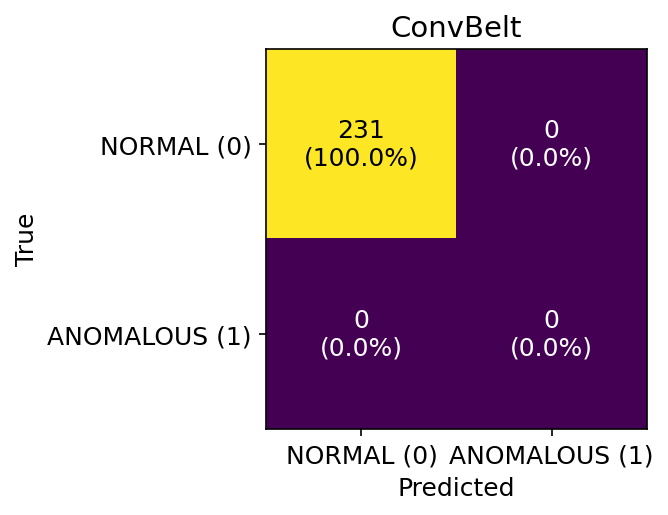

c:\Users\XN2\miniconda3\envs\pt\lib\site-packages\sklearn\metrics\_classification.py:386: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\XN2\miniconda3\envs\pt\lib\site-packages\sklearn\metrics\_classification.py:708: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)


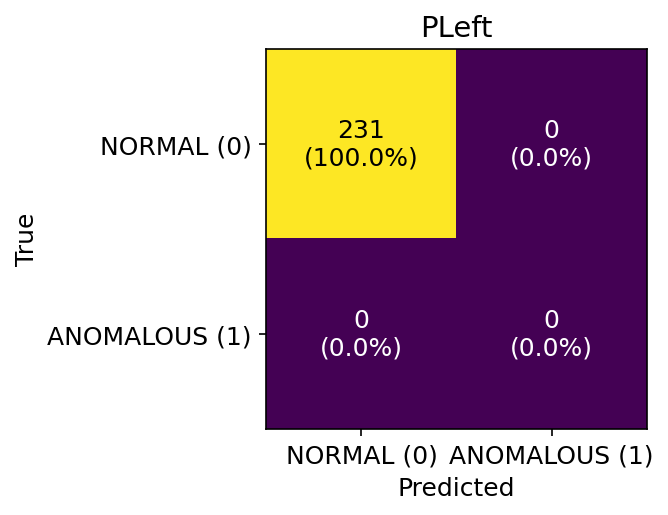

c:\Users\XN2\miniconda3\envs\pt\lib\site-packages\sklearn\metrics\_classification.py:386: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\XN2\miniconda3\envs\pt\lib\site-packages\sklearn\metrics\_classification.py:708: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)


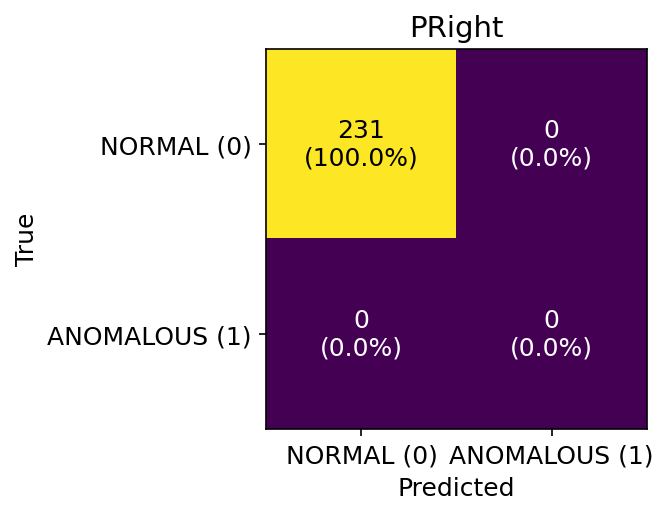

c:\Users\XN2\miniconda3\envs\pt\lib\site-packages\sklearn\metrics\_classification.py:386: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\XN2\miniconda3\envs\pt\lib\site-packages\sklearn\metrics\_classification.py:708: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)


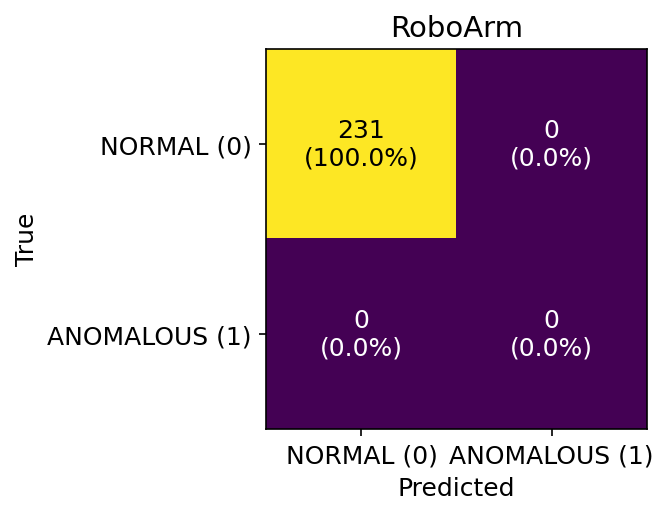

Overall: {'TP': 0, 'TN': 924, 'FP': 0, 'FN': 0, 'support_pos': 0, 'support_neg': 924, 'support_all': 924, 'accuracy': 1.0, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'specificity': 1.0, 'balanced_accuracy': 0.5, 'fpr': 0.0, 'fnr': 0.0, 'cohen_kappa': nan}


,TP,TN,FP,FN,support_pos,support_neg,support_all,accuracy,precision,recall,f1,specificity,balanced_accuracy,fpr,fnr,cohen_kappa,component
0,0,231,0,0,0,231,231,1.0,0.0,0.0,0.0,1.0,0.5,0.0,0.0,NaN,ConvBelt
1,0,231,0,0,0,231,231,1.0,0.0,0.0,0.0,1.0,0.5,0.0,0.0,NaN,PLeft
2,0,231,0,0,0,231,231,1.0,0.0,0.0,0.0,1.0,0.5,0.0,0.0,NaN,PRight
3,0,231,0,0,0,231,231,1.0,0.0,0.0,0.0,1.0,0.5,0.0,0.0,NaN,RoboArm


In [106]:
if anomaly_level == 'componentlevel':
    metrics_by_sa, cms_by_sa, overall_metrics, merged_df = evaluate_inference_by_group(
        df_inference_component_level,
        df_anom_meta,
        group_col="component",    # or "zone", "region", etc.
        plot_confusion=True,        # set False to skip plots
        normalize_cm=True,          # show % alongside counts
        font_size=12,
        save_path=f'{paths.path_inference_results}',
    )

    print("Overall:", overall_metrics)     # quick glance
    display(metrics_by_sa)                 # nice table in notebooks
    # cms_by_sa is a dict: {safety_area_value: 2x2 numpy array}
